# Ingesta y exploracion de datos HISTORICO_SUERTES.xlsx

In [ ]:
# libreria que nos permite manipular datoss en formato de tablas (DataFrames)
import pandas as pd

# Cargar el archivo Excel
df = pd.read_excel('../../data/raw/HISTORICO_SUERTES.xlsx')

# Visualizar las primeras filas
print("Primeras 5 filas del dataset:")
print(df.head())


Primeras 5 filas del dataset:
   Período  Hacienda             Nombre  Zona  Tenencia Suerte       Suelo  \
0   201701     80493          LA CONCHA  IP02      51.0   002A   CANTARINA   
1   201701     81284    UKRANIA INCAUCA  IP05      81.0   039B         NaN   
2   201701     80203      EL AMPARO SAA  IP05      31.0    007  CORINTIAS    
3   201701     81380  SAN JUDAS INCAUCA  IP05      82.0   013A         NaN   
4   201701     80298               JAVA  IP06      31.0   025A     GALPON    

   Area Neta  Dist Km   Variedad  ...  Humedad Rel Media Ciclo  \
0       6.00      4.3    CC85-92  ...                      NaN   
1       1.45      NaN    CC85-92  ...                      NaN   
2       8.24     23.0  CC01-1228  ...                      NaN   
3       1.05     66.5  CC01-1940  ...                      NaN   
4       4.53     17.0  RB73-2223  ...                      NaN   

  Oscilacion Temp Med 0-3 Oscilacion Temp Ciclo Sum Oscilacion Temp Ciclo  \
0                     NaN  

In [ ]:
# Información general del DataFrame
print("\nInformación del DataFrame (.info()):")
df.info()


Información del DataFrame (.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 85 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Período                    21027 non-null  int64         
 1   Hacienda                   21027 non-null  int64         
 2   Nombre                     21027 non-null  object        
 3   Zona                       21027 non-null  object        
 4   Tenencia                   21026 non-null  float64       
 5   Suerte                     21027 non-null  object        
 6   Suelo                      17269 non-null  object        
 7   Area Neta                  21027 non-null  float64       
 8   Dist Km                    21022 non-null  float64       
 9   Variedad                   21027 non-null  object        
 10  Cod.Estado #               21027 non-null  int64         
 11  Cod.Estado                 21

In [4]:
# Estadísticas descriptivas para variables numéricas
print("\nEstadísticas Descriptivas (.describe()):")
print(df.describe())


Estadísticas Descriptivas (.describe()):
             Período      Hacienda      Tenencia     Area Neta       Dist Km  \
count   21027.000000  21027.000000  21026.000000  21027.000000  21022.000000   
mean   202039.708708  80679.334427     46.448730      8.642948     25.311806   
min    201701.000000  80100.000000     11.000000      0.004000      1.100000   
25%    201812.000000  80247.000000     31.000000      3.310000     12.000000   
50%    202010.000000  80453.000000     51.000000      7.000000     21.900000   
75%    202209.000000  81104.000000     51.000000     12.075000     32.700000   
max    202407.000000  82557.000000     91.000000     65.000000    155.000000   
std       216.642895    590.030150     21.513498      7.049533     18.237344   

       Cod.Estado #                      F.Siembra  \
count  21027.000000                          21027   
mean       4.261806  2015-03-11 18:18:44.839492096   
min        0.000000            1986-04-30 00:00:00   
25%        1.000000  

In [5]:
# Búsqueda de duplicados
print(f"\nNúmero de filas duplicadas: {df.duplicated().sum()}")


Número de filas duplicadas: 0


Teninedo en cuenta que en nuestra base de datos no se tienen registros duplicados, eso quiere decir que todos los datos son recogidos directamente en el campo

In [ ]:
# Tipos de datos de cada columna
df.dtypes

Período                    int64
Hacienda                   int64
Nombre                    object
Zona                      object
Tenencia                 float64
                          ...   
Radiacion Solar Ciclo    float64
Precipitacion 0_3        float64
Precipitacion Ciclo      float64
Evaporacion 0-3          float64
Evaporacion Ciclo        float64
Length: 85, dtype: object

In [ ]:
# Análisis de valores nulos en cada columna (y su conteo) 
valores_nulos = df.isnull().sum()
# Filtrar solo las columnas con valores nulos y mostrar el conteo
valores_nulos = valores_nulos[valores_nulos > 0]
print(valores_nulos)

Tenencia                         1
Suelo                         3758
Dist Km                          5
D.S.                         13859
Ult.Riego                    12557
Cod. T.Cultivo                   2
Cultivo                          2
Fec.Madur.                    9775
Producto                      9778
Dosis Madurante                104
Semanas mad.                  9775
Ton.Azucar                     241
Rdto                           267
TAH                            241
TAHM                           241
Sac.Caña Precosecha           1098
Edad.Precosecha              12108
%Sac.Caña                      449
%Sac.Muestreadora             1858
%ATR                           522
KATRHM                         522
%Fibra Caña                   1858
%AR Jugo                      2124
%ME Min                       1722
%ME Veg                       1720
%ME Tot                       1720
Brix                           267
Pureza                         269
Vejez               

In [ ]:
# librerias para visualizacion de datos
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

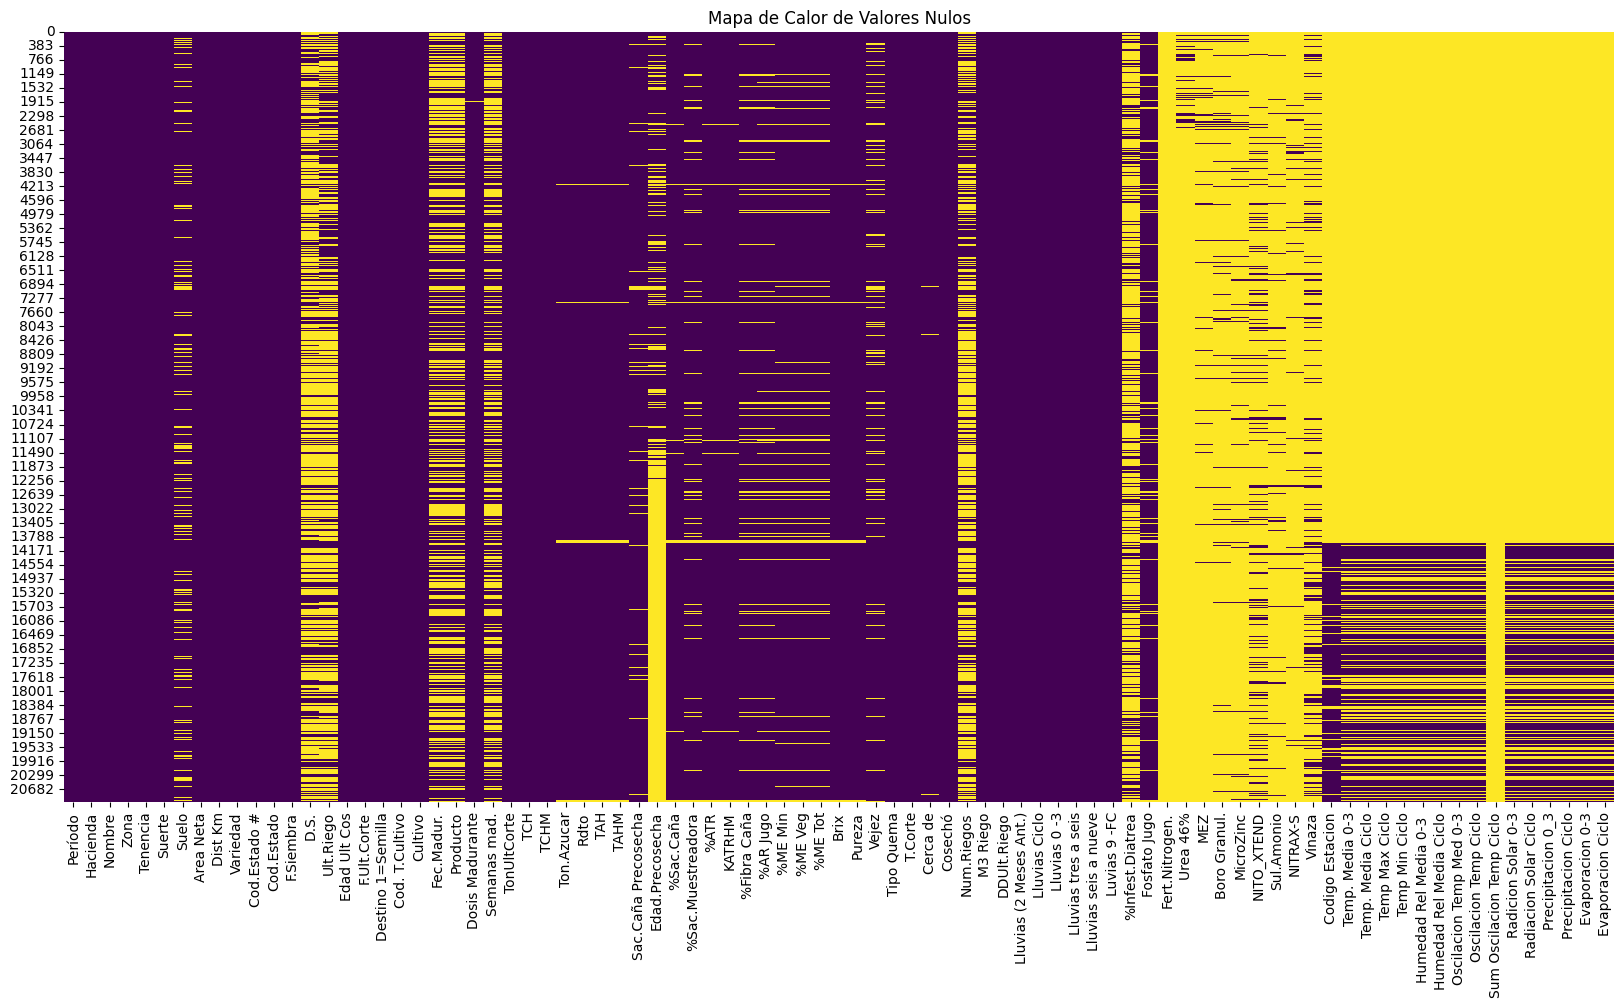

In [9]:
# Visualización de valores nulos
plt.figure(figsize=(20, 10))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos')
plt.show()

Teniendo en cuenta el bloque masivo de nulos a la derecha indica que las variables climáticas del “Ciclo” (temperatura, humedad, radiación, precipitación, evaporación) presentan muy baja cobertura, probablemente por capturas condicionadas a estación/lote o por no aplicabilidad del cálculo; esto sugiere un mecanismo de pérdida MAR/MNAR más que MCAR. Operativamente, estas columnas arriesgan sesgar modelos, elevar la varianza y reducir drásticamente el n efectivo si se exige completitud. Recomiendo: (1) depuración por umbral (p.ej., descartar >90% nulos salvo variables críticas); (2) enriquecimiento externo (join con series meteorológicas oficiales por geohash/fecha) y imputación estratificada por región-mes/estación o modelos KNN/GBM cuando se justifique; (3) evitar imputar si una métrica actúa como target; y (4) validar impacto vía ablation studies y permutation importance, documentando el riesgo de sesgo de disponibilidad si la medición se asocia a desempeño.

In [10]:
# Porcentaje de nulos y cardinalidad por columna
null_percentage = (df.isnull().sum() / len(df)) * 100
cardinality = df.nunique()
eda_summary = pd.DataFrame({
    'Porcentaje de Nulos (%)': null_percentage ,
    'Cardinalidad (Valores Únicos)': cardinality
})
print("\nResumen de Nulos y Cardinalidad:")
print(eda_summary.sort_values(by='Porcentaje de Nulos (%)', ascending=False))


Resumen de Nulos y Cardinalidad:
                           Porcentaje de Nulos (%)  \
Sum Oscilacion Temp Ciclo               100.000000   
Fert.Nitrogen.                          100.000000   
Urea 46%                                 96.561564   
NITRAX-S                                 96.442669   
MEZ                                      95.382128   
...                                            ...   
Lluvias seis a nueve                      0.000000   
Luvias 9 -FC                              0.000000   
Lluvias tres a seis                       0.000000   
Lluvias 0 -3                              0.000000   
Lluvias Ciclo                             0.000000   

                           Cardinalidad (Valores Únicos)  
Sum Oscilacion Temp Ciclo                              0  
Fert.Nitrogen.                                         0  
Urea 46%                                             413  
NITRAX-S                                             430  
MEZ                   

Variables con Alto Porcentaje de Nulos (>50%): Sul.Amonio, Boro Granul., NITRAX-S, MicroZinc, Urea 46%, NITO_XTEND, MEZ, Vinaza son columnas relacionadas con fertilizantes y tienen una cantidad masiva de datos faltantes. Serán descartadas, que presentan >50% de valores nulos, con patrón de pérdida no aleatorio y baja utilidad predictiva neta bajo esquemas de completitud. Para evitar reducción severa del tamaño muestral y sesgos de disponibilidad, se excluirán del dataset base según regla de umbral



Cardinalidad Elevada: Hacienda, Nombre, y Suerte tienen una alta cardinalidad, lo que confirma que son identificadores únicos y no deben usarse como características predictivas. 

En cambio, F.Siembra, F.Ult.Corte y Ult.Riego son fechas con mucha unicidad pero altamente informativas tras su ingeniería de variables: conviene derivar antigüedad del cultivo (días desde siembra), tiempo desde último corte/riego, componentes estacionales (mes, trimestre, semana del año), indicadores de campaña (lluvias/seco) e incluso lags y ventanas móviles coherentes con la cronología. Al construir estas features, asegurarse de respetar la causalidad temporal (nada posterior al objetivo) y evaluar su aporte.

Columnas Problemáticas: Columnas como Area Neta y Dist Km tienen valores no numéricos (' o ,) que deben ser limpiados antes del análisis.

## Análisis de las Variables Objetivo (TCH y %Sac.Caña)


In [11]:
df[['TCH', '%Sac.Caña']].describe()

,TCH,%Sac.Caña
count,21027.000000,20578.000000
mean,129.608509,12.320202
std,32.846029,1.145738
min,1.573653,7.086000
25%,108.691426,11.619000
50%,129.479600,12.370650
75%,150.407607,13.087500
max,401.045947,18.400000


In [12]:
df[['TCH', '%Sac.Caña']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TCH        21027 non-null  float64
 1   %Sac.Caña  20578 non-null  float64
dtypes: float64(2)
memory usage: 328.7 KB


In [13]:
# Limpieza y conversión de variables objetivo a numéricas
df['TCH'] = pd.to_numeric(df['TCH'], errors='coerce')
df['%Sac.Caña'] = pd.to_numeric(df['%Sac.Caña'], errors='coerce')

No, nunca debemos imputar la variable objetivo.

Es una práctica correcta y necesaria imputar los datos de las variables predictoras (features), pero es un error fundamental imputar la variable objetivo (target)

In [14]:
# Eliminar filas donde los objetivos son nulos
df.dropna(subset=['TCH', '%Sac.Caña'], inplace=True)

In [15]:
df

,Período,Hacienda,Nombre,Zona,Tenencia,Suerte,Suelo,Area Neta,Dist Km,Variedad,...,Humedad Rel Media Ciclo,Oscilacion Temp Med 0-3,Oscilacion Temp Ciclo,Sum Oscilacion Temp Ciclo,Radicion Solar 0-3,Radiacion Solar Ciclo,Precipitacion 0_3,Precipitacion Ciclo,Evaporacion 0-3,Evaporacion Ciclo
0,201701,80493,LA CONCHA,IP02,51.0,002A,CANTARINA,6.00,4.3,CC85-92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,201701,81284,UKRANIA INCAUCA,IP05,81.0,039B,NaN,1.45,NaN,CC85-92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201701,80203,EL AMPARO SAA,IP05,31.0,007,CORINTIAS,8.24,23.0,CC01-1228,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,201701,81380,SAN JUDAS INCAUCA,IP05,82.0,013A,NaN,1.05,66.5,CC01-1940,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,201701,80298,JAVA,IP06,31.0,025A,GALPON,4.53,17.0,RB73-2223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20970,202406,80289,EL CARMEN MEJIA,IP01,31.0,001,NIMA,7.96,5.0,CC01-1940,...,78.535,17.8,30.478,NaN,461.136,445.221,182.4,1120.3,518.3,1950.7
20971,202406,82506,EL HIGUERON EMPRESA,IP05,11.0,005A,JOYA,42.74,42.0,CC01-1940,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20972,202406,82510,EL CARMEN VELASCO,IP01,31.0,001A,NIMA,1.32,5.0,CC01-1940,...,78.647,17.8,30.094,NaN,440.282,443.181,202.7,1144.3,470.7,2054.0
20973,202406,82530,ARAUCA,IP05,31.0,006,MANUELITA,6.27,34.7,CC05-430,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


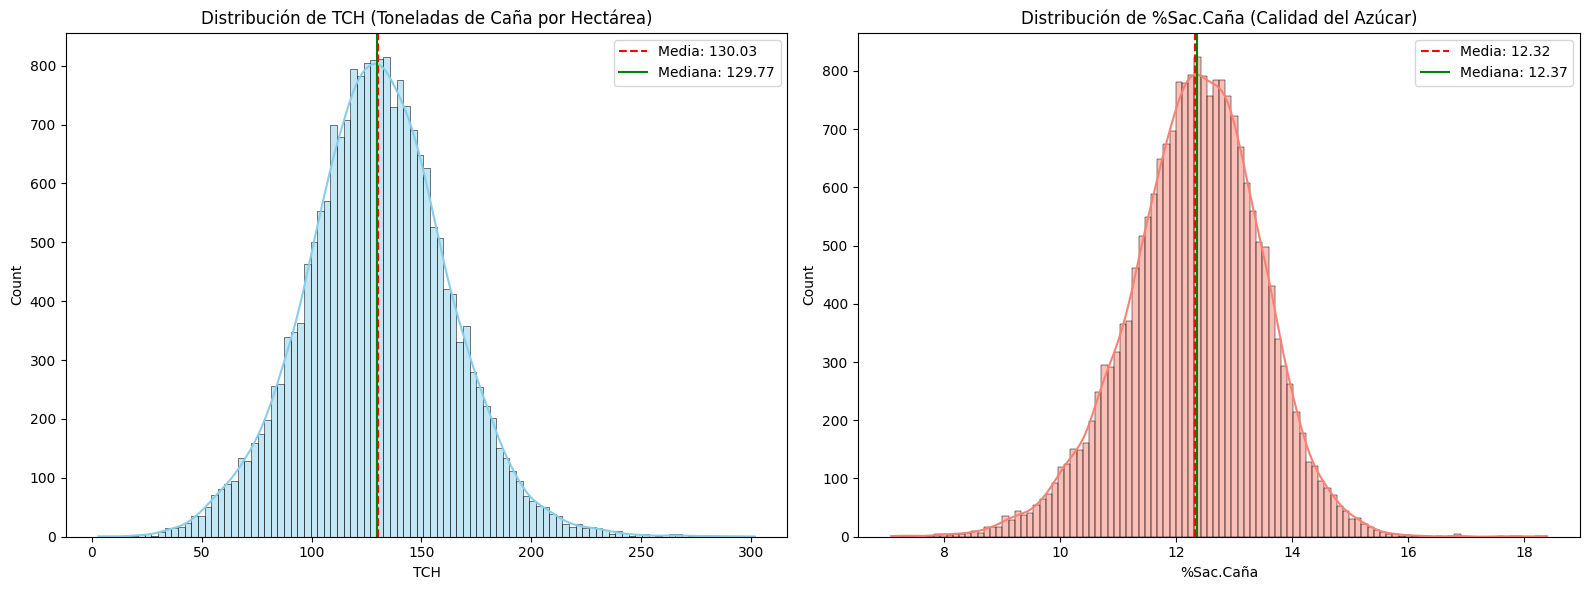

In [16]:
# Visualización de la distribución de TCH y %Sac.Caña
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['TCH'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de TCH (Toneladas de Caña por Hectárea)')
axes[0].axvline(df['TCH'].mean(), color='red', linestyle='--', label=f"Media: {df['TCH'].mean():.2f}")
axes[0].axvline(df['TCH'].median(), color='green', linestyle='-', label=f"Mediana: {df['TCH'].median():.2f}")
axes[0].legend()

sns.histplot(df['%Sac.Caña'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de %Sac.Caña (Calidad del Azúcar)')
axes[1].axvline(df['%Sac.Caña'].mean(), color='red', linestyle='--', label=f"Media: {df['%Sac.Caña'].mean():.2f}")
axes[1].axvline(df['%Sac.Caña'].median(), color='green', linestyle='-', label=f"Mediana: {df['%Sac.Caña'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

TCH: presenta sesgo positivo (cola derecha). La media > mediana confirma que existen pocas suertes con rendimientos excepcionalmente altos que elevan el promedio. Implicaciones: métricas robustas (mediana/RIQ) describen mejor la tendencia central; conviene detectar outliers y, si se modela con supuestos de normalidad o se usan métodos sensibles a colas, evaluar transformaciones o modelos robustos.

%Sac.Caña: distribución casi simétrica y leptocúrtica alrededor del 12%; la media cercana a la mediana sugiere estabilidad del indicador y menor impacto de atípicos. Es un buen candidato para técnicas que asumen normalidad; aun así, verificar heterocedasticidad por variedad/edad y considerar estacionalidad. En conjunto, TCH requiere tratamiento de colas y atípicos; %Sac.Caña puede usarse prácticamente “tal cual”, con controles estándar de calidad de datos.

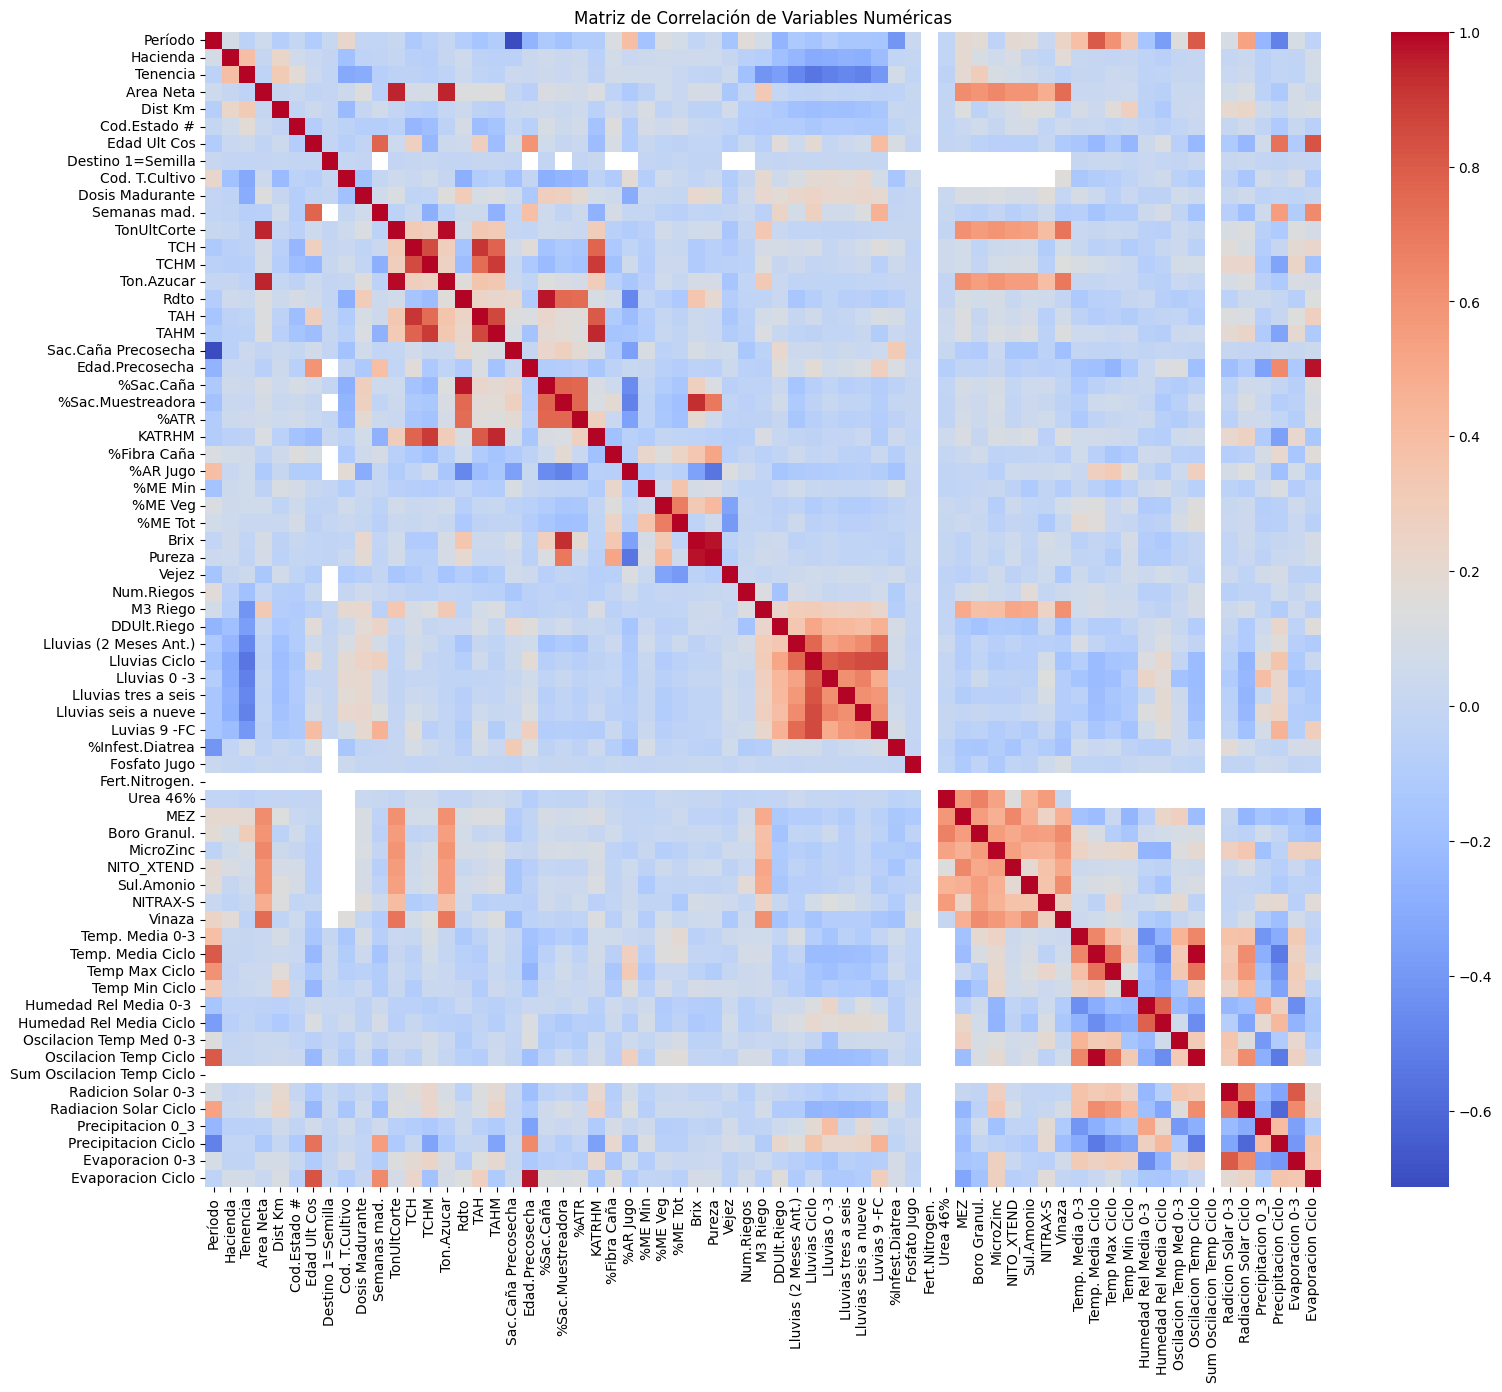


Correlaciones más fuertes con TCH:
TCH                  1.000000
TAH                  0.907843
TCHM                 0.847381
TAHM                 0.774089
KATRHM               0.767925
TonUltCorte          0.316029
Ton.Azucar           0.289917
Edad Ult Cos         0.280524
Evaporacion Ciclo    0.230284
Evaporacion 0-3      0.185291
Name: TCH, dtype: float64

Correlaciones más fuertes con %Sac.Caña:
%Sac.Caña              1.000000
Rdto                   0.970430
%Sac.Muestreadora      0.768583
%ATR                   0.763754
Dosis Madurante        0.288158
Brix                   0.278750
Sac.Caña Precosecha    0.229690
TAH                    0.222309
TAHM                   0.195322
Ton.Azucar             0.140788
Name: %Sac.Caña, dtype: float64


In [17]:
# Seleccionar solo columnas numéricas para la matriz de correlación
numeric_cols = df.select_dtypes(include=np.number)
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".1f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# Correlaciones específicas con las variables objetivo
print("\nCorrelaciones más fuertes con TCH:")
print(correlation_matrix['TCH'].sort_values(ascending=False).head(10))
print("\nCorrelaciones más fuertes con %Sac.Caña:")
print(correlation_matrix['%Sac.Caña'].sort_values(ascending=False).head(10))

La matriz de correlaciones las variables muy correlacionadas entre sí (>|0.85|) aportan información redundante y pueden causar multicolinealidad: en modelos lineales infla las varianzas (coeficientes inestables, p-valores engañosos), empeora la generalización y facilita overfitting; en árboles/boosting aumenta complejidad sin ganar señal. Por eso, con umbral_max = 0.85 se recomienda quedarte con una de cada bloque rojo (la que tenga mayor correlación con el target o mejor cobertura) y descartar el resto. Con umbral_min = 0.3, las variables cuya correlación (con el target) quede por debajo de |0.3| suelen tener baja potencia predictiva y pueden excluirse salvo justificación de negocio o efectos no lineales. En resumen: de cada “mancha roja” del mapa conserva una sola variable fuerte, y evita variables casi azules con el objetivo.

# Indicaciones para la matriz de correlacion

Interpretación común de la correlación (|r|):

0.0 – 0.1 → correlación despreciable (no útil como predictor).

0.1 – 0.3 → correlación débil (aporta poco, pero puede servir combinada con otras).

0.3 – 0.5 → correlación moderada (empieza a ser relevante).

0.5 – 0.7 → correlación fuerte (muy buen predictor).

0.7 – 0.9 → correlación muy fuerte (a veces indica redundancia con otra variable).

0.9 – 1.0 → casi duplicada (puede ser descartada por colinealidad).

Si buscas buenas predictoras iniciales, céntrate en el rango 0.3 ≤ |r| ≤ 0.7.

Si es mayor a 0.8 o 0.9, revisa si está duplicando la información de otra variable.

Si es menor a 0.2, probablemente no ayude mucho (salvo que el modelo capte relaciones no lineales).

In [18]:
# Correlaciones con TCH entre 0.6 y 0.8
cor_tch = correlation_matrix['TCH']
cor_tch_filtradas = cor_tch[(cor_tch.abs() > 0.6) & (cor_tch.abs() < 0.8)]
print("\nCorrelaciones con TCH entre 0.6 y 0.8:")
print(cor_tch_filtradas)


Correlaciones con TCH entre 0.6 y 0.8:
TAHM      0.774089
KATRHM    0.767925
Name: TCH, dtype: float64


In [19]:
# Correlaciones con %Sac.Caña entre 0.6 y 0.8
cor_sac = correlation_matrix['%Sac.Caña']
cor_sac_filtradas = cor_sac[(cor_sac.abs() > 0.6) & (cor_sac.abs() < 0.8)]
print("\nCorrelaciones con %Sac.Caña entre 0.6 y 0.8:")
print(cor_sac_filtradas)


Correlaciones con %Sac.Caña entre 0.6 y 0.8:
%Sac.Muestreadora    0.768583
%ATR                 0.763754
Name: %Sac.Caña, dtype: float64


In [20]:
# Seleccionar solo columnas numéricas para la matriz de correlación
numeric_cols = df.select_dtypes(include=np.number)
correlation_matrix = numeric_cols.corr()

## Variables a no tener en cuenta por tener una correlacion alta

In [21]:
umbral_max = 0.85
umbral_min = 0.3


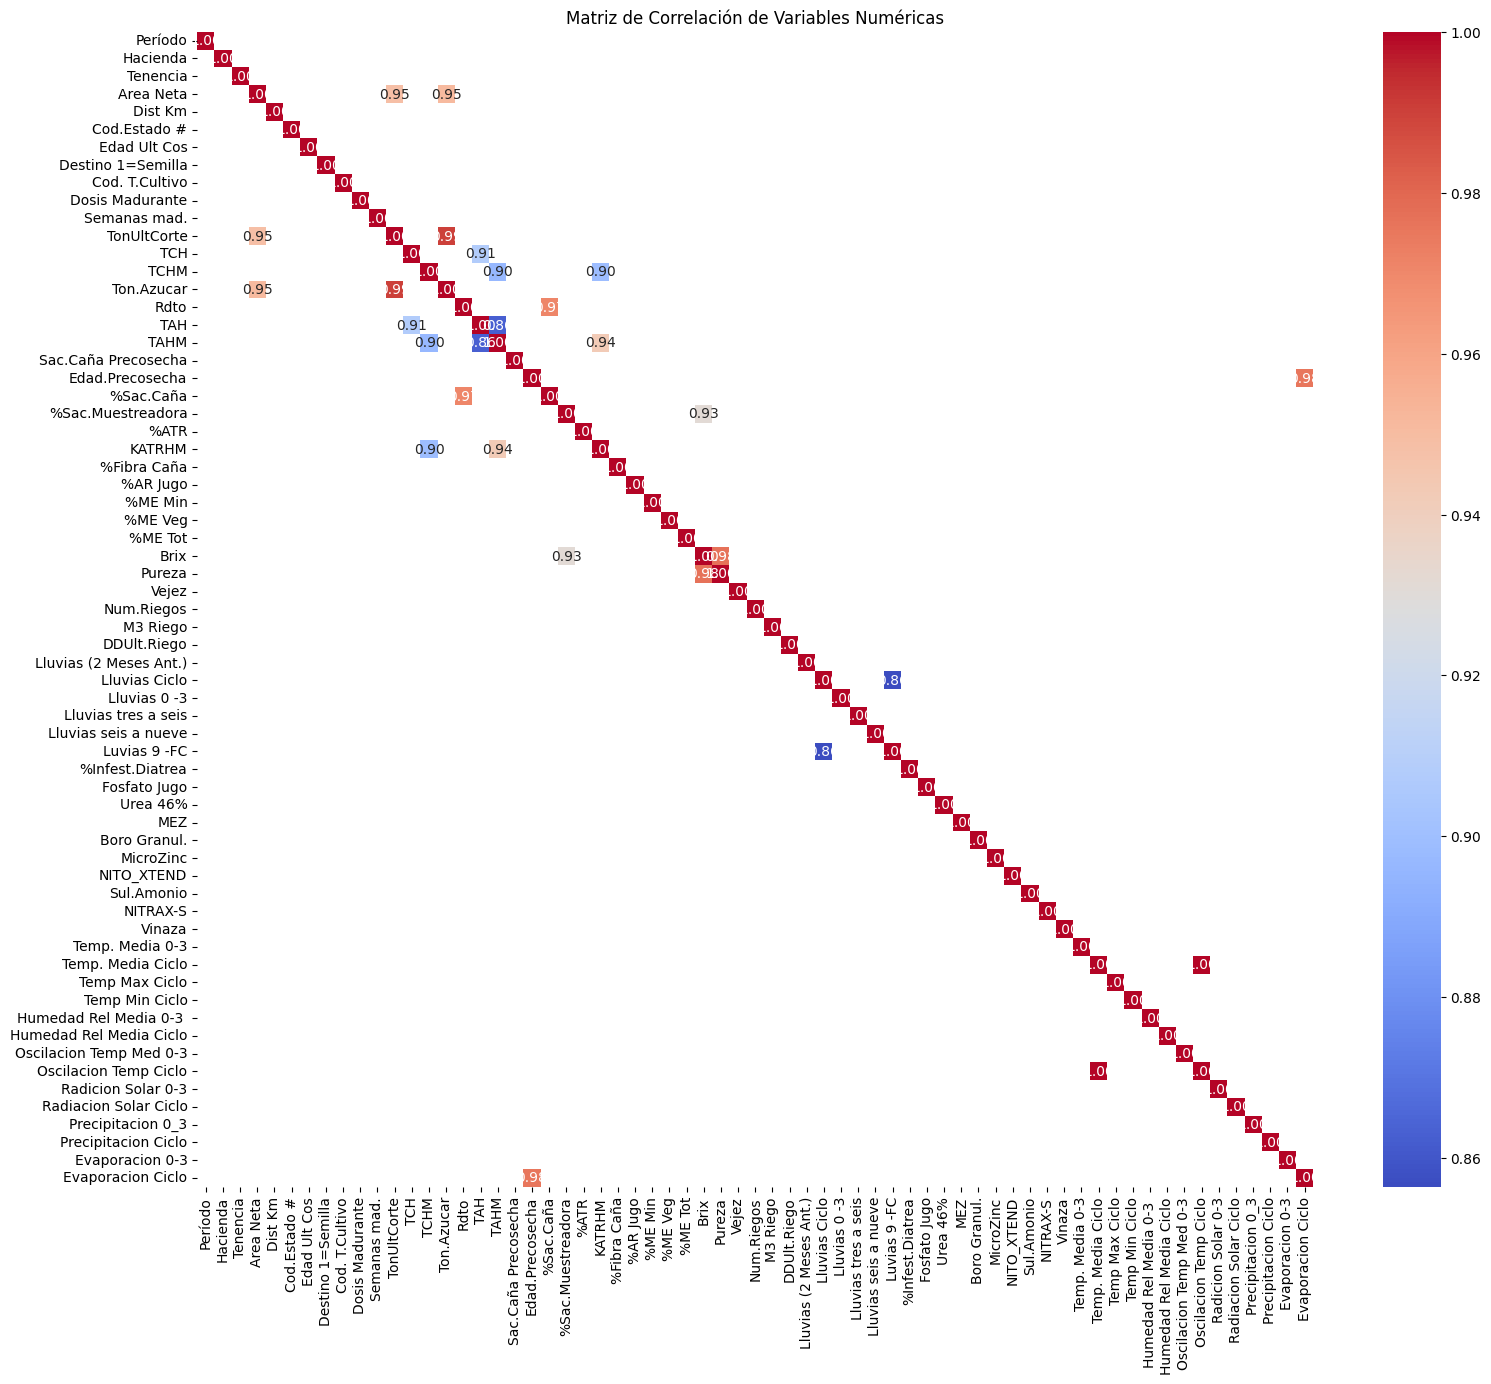


Correlaciones más fuertes con TCH:
TCH                  1.000000
TAH                  0.907843
TCHM                 0.847381
TAHM                 0.774089
KATRHM               0.767925
TonUltCorte          0.316029
Ton.Azucar           0.289917
Edad Ult Cos         0.280524
Evaporacion Ciclo    0.230284
Evaporacion 0-3      0.185291
Name: TCH, dtype: float64

Correlaciones más fuertes con %Sac.Caña:
%Sac.Caña              1.000000
Rdto                   0.970430
%Sac.Muestreadora      0.768583
%ATR                   0.763754
Dosis Madurante        0.288158
Brix                   0.278750
Sac.Caña Precosecha    0.229690
TAH                    0.222309
TAHM                   0.195322
Ton.Azucar             0.140788
Name: %Sac.Caña, dtype: float64


In [22]:
cor_tch_filtradas = correlation_matrix[(correlation_matrix.abs() >= umbral_max)]
# Eliminar filas y columnas con solo NaN
cor_tch_filtradas = cor_tch_filtradas.dropna(how="all", axis=0)  # elimina filas vacías
cor_tch_filtradas = cor_tch_filtradas.dropna(how="all", axis=1)  # elimina columnas vacías

plt.figure(figsize=(18, 15))
sns.heatmap(cor_tch_filtradas, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# Correlaciones específicas con las variables objetivo
print("\nCorrelaciones más fuertes con TCH:")
print(correlation_matrix['TCH'].sort_values(ascending=False).head(10))
print("\nCorrelaciones más fuertes con %Sac.Caña:")
print(correlation_matrix['%Sac.Caña'].sort_values(ascending=False).head(10))

In [23]:
def variables_alta_correlacion(df, umbral):
    """
    Retorna una lista de pares de variables cuya correlación 
    absoluta es mayor al umbral (default=0.8).
    """
    # Matriz de correlación
    corr_matrix = df.corr().abs()
    
    # Seleccionar parte superior de la matriz para no repetir pares
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Encontrar pares con correlación mayor al umbral
    variables_correlacionadas = [
        (col, row, upper.loc[row, col]) 
        for col in upper.columns 
        for row in upper.index 
        if upper.loc[row, col] > umbral
    ]
    
    return variables_correlacionadas

correlaciones_fuertes = variables_alta_correlacion(numeric_cols, umbral=umbral_max)

for var1, var2, corr in correlaciones_fuertes:
    print(f"{var1} - {var2}: {corr:.2f}") 

TonUltCorte - Area Neta: 0.95
Ton.Azucar - Area Neta: 0.95
Ton.Azucar - TonUltCorte: 0.99
TAH - TCH: 0.91
TAHM - TCHM: 0.90
TAHM - TAH: 0.86
%Sac.Caña - Rdto: 0.97
KATRHM - TCHM: 0.90
KATRHM - TAHM: 0.94
Brix - %Sac.Muestreadora: 0.93
Pureza - Brix: 0.98
Luvias 9 -FC - Lluvias Ciclo: 0.86
Oscilacion Temp Ciclo - Temp. Media Ciclo: 1.00
Evaporacion Ciclo - Edad.Precosecha: 0.98


## Variables a seleccionar que tienen buena correlacion

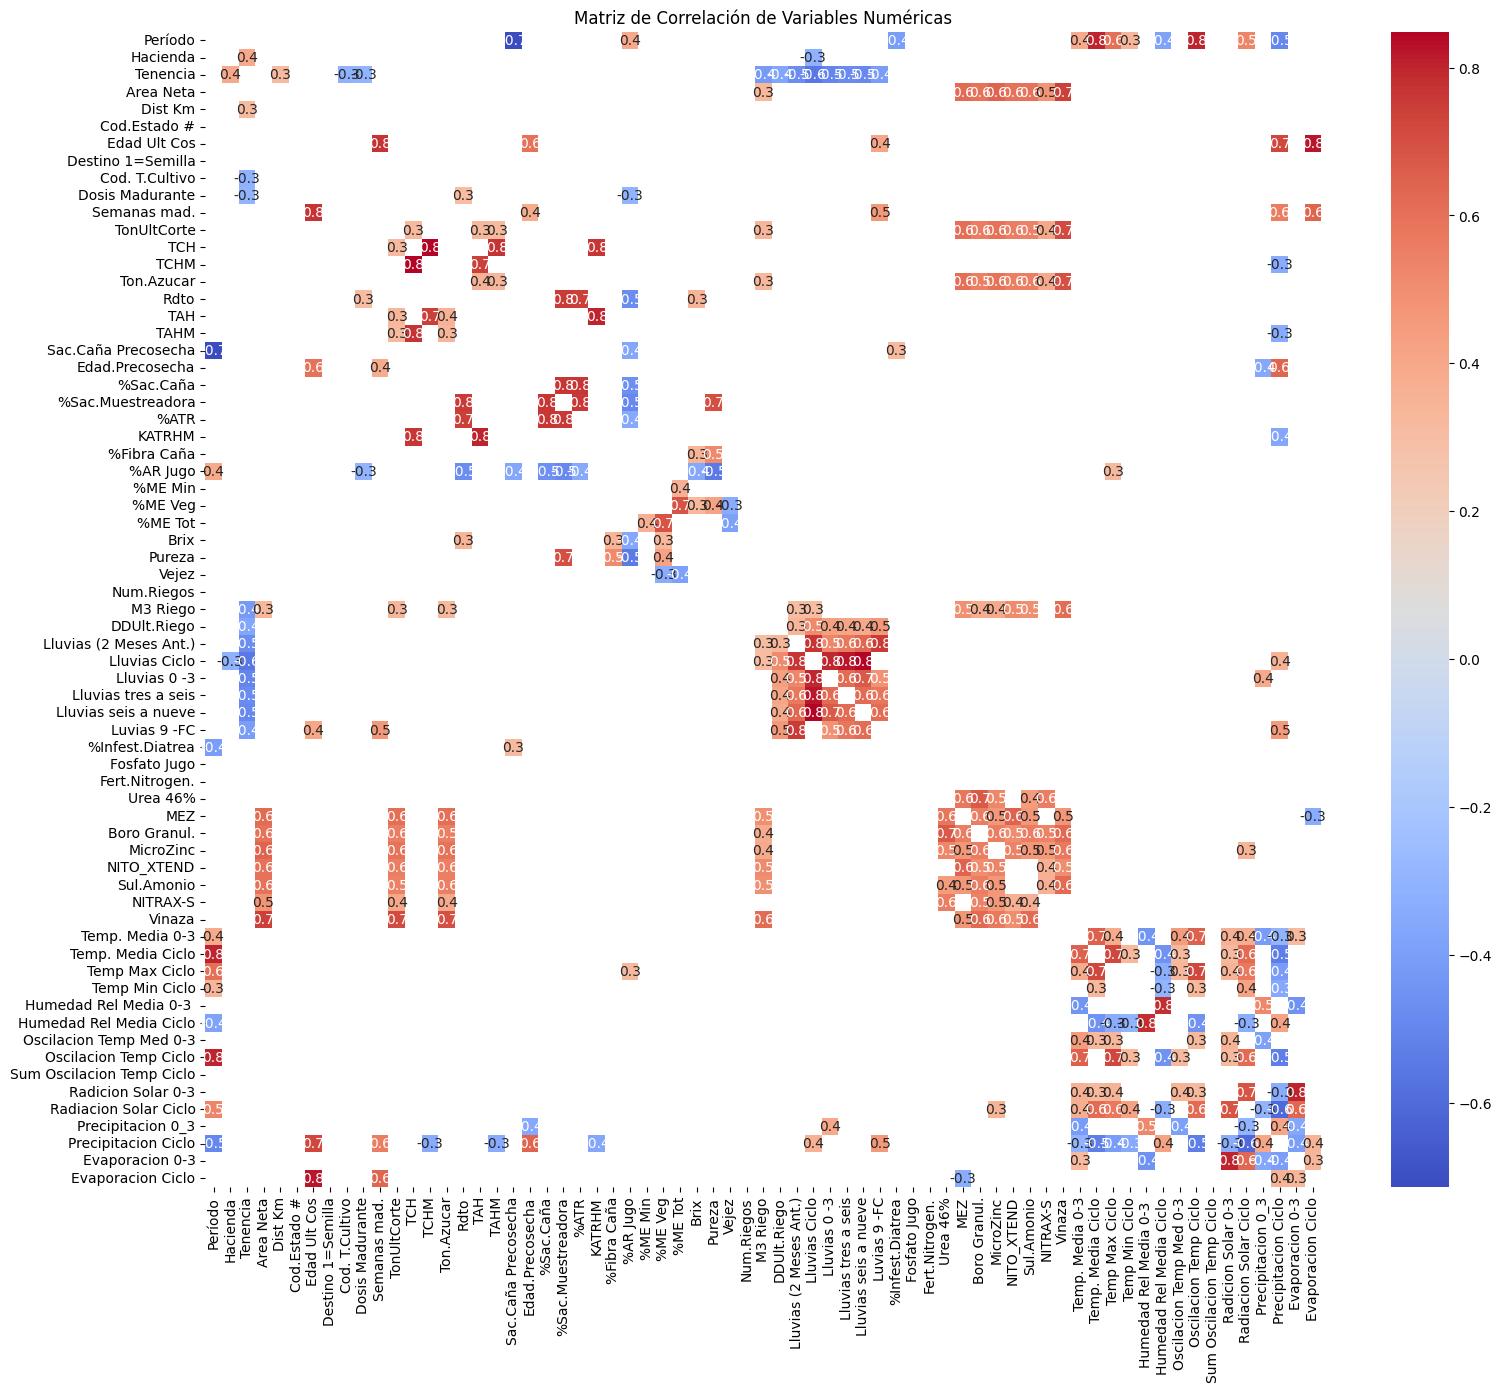


Correlaciones más fuertes con TCH:
TCH                  1.000000
TAH                  0.907843
TCHM                 0.847381
TAHM                 0.774089
KATRHM               0.767925
TonUltCorte          0.316029
Ton.Azucar           0.289917
Edad Ult Cos         0.280524
Evaporacion Ciclo    0.230284
Evaporacion 0-3      0.185291
Name: TCH, dtype: float64

Correlaciones más fuertes con %Sac.Caña:
%Sac.Caña              1.000000
Rdto                   0.970430
%Sac.Muestreadora      0.768583
%ATR                   0.763754
Dosis Madurante        0.288158
Brix                   0.278750
Sac.Caña Precosecha    0.229690
TAH                    0.222309
TAHM                   0.195322
Ton.Azucar             0.140788
Name: %Sac.Caña, dtype: float64


In [24]:
# Seleccionar solo columnas numéricas para la matriz de correlación
numeric_cols = df.select_dtypes(include=np.number)
correlation_matrix = numeric_cols.corr()
cor_tch_filtradas = correlation_matrix[(correlation_matrix.abs() >= umbral_min) & (correlation_matrix.abs() <= umbral_max)]

plt.figure(figsize=(18, 15))
sns.heatmap(cor_tch_filtradas, annot=True, cmap='coolwarm', fmt=".1f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# Correlaciones específicas con las variables objetivo
print("\nCorrelaciones más fuertes con TCH:")
print(correlation_matrix['TCH'].sort_values(ascending=False).head(10))
print("\nCorrelaciones más fuertes con %Sac.Caña:")
print(correlation_matrix['%Sac.Caña'].sort_values(ascending=False).head(10))

In [25]:
correlaciones_uso = variables_alta_correlacion(numeric_cols, umbral=umbral_min)

for var1, var2, corr in correlaciones_uso:
    print(f"{var1} - {var2}: {corr:.2f}") 

Tenencia - Hacienda: 0.40
Dist Km - Tenencia: 0.31
Cod. T.Cultivo - Tenencia: 0.31
Dosis Madurante - Tenencia: 0.30
Semanas mad. - Edad Ult Cos: 0.77
TonUltCorte - Area Neta: 0.95
TCH - TonUltCorte: 0.32
TCHM - TCH: 0.85
Ton.Azucar - Area Neta: 0.95
Ton.Azucar - TonUltCorte: 0.99
Rdto - Dosis Madurante: 0.31
TAH - TonUltCorte: 0.34
TAH - TCH: 0.91
TAH - TCHM: 0.74
TAH - Ton.Azucar: 0.35
TAHM - TonUltCorte: 0.32
TAHM - TCH: 0.77
TAHM - TCHM: 0.90
TAHM - Ton.Azucar: 0.34
TAHM - TAH: 0.86
Sac.Caña Precosecha - Período: 0.71
Edad.Precosecha - Edad Ult Cos: 0.60
Edad.Precosecha - Semanas mad.: 0.38
%Sac.Caña - Rdto: 0.97
%Sac.Muestreadora - Rdto: 0.75
%Sac.Muestreadora - %Sac.Caña: 0.77
%ATR - Rdto: 0.74
%ATR - %Sac.Caña: 0.76
%ATR - %Sac.Muestreadora: 0.76
KATRHM - TCH: 0.77
KATRHM - TCHM: 0.90
KATRHM - TAH: 0.80
KATRHM - TAHM: 0.94
%AR Jugo - Período: 0.40
%AR Jugo - Dosis Madurante: 0.30
%AR Jugo - Rdto: 0.47
%AR Jugo - Sac.Caña Precosecha: 0.36
%AR Jugo - %Sac.Caña: 0.46
%AR Jugo - %Sac

### Para TCH: 
No hay variables con una correlación superior a 0.6. Las más cercanas son TonUltCorte (0.58) y Num.Riegos (0.33), lo que sugiere que la productividad anterior y el riego son factores importantes, pero la relación no es extremadamente fuerte.

### Para %Sac.Caña:
Positivas: %Sac.Muestreadora (0.97) y %ATR (0.98) son casi perfectamente correlacionadas. Esto es esperado, ya que son métricas de calidad muy similares. Pureza (0.81) y Brix (0.80) también muestran una fuerte correlación positiva, lo cual es lógicamente consistente.

Negativas: %Fibra Caña (-0.66) tiene una fuerte correlación negativa, indicando que a mayor fibra, menor es la concentración de sacarosa.

# Seleccion de variables categoricas

In [26]:
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()
print("Categorical Features:", categorical_features)
print("Categorical Features:", len(categorical_features))


Categorical Features: ['Nombre', 'Zona', 'Suerte', 'Suelo', 'Variedad', 'Cod.Estado', 'F.Siembra', 'D.S.', 'Ult.Riego', 'F.Ult.Corte', 'Cultivo', 'Fec.Madur.', 'Producto', 'Tipo Quema', 'T.Corte', 'Cerca de', 'Cosechó', 'Codigo Estacion']
Categorical Features: 18


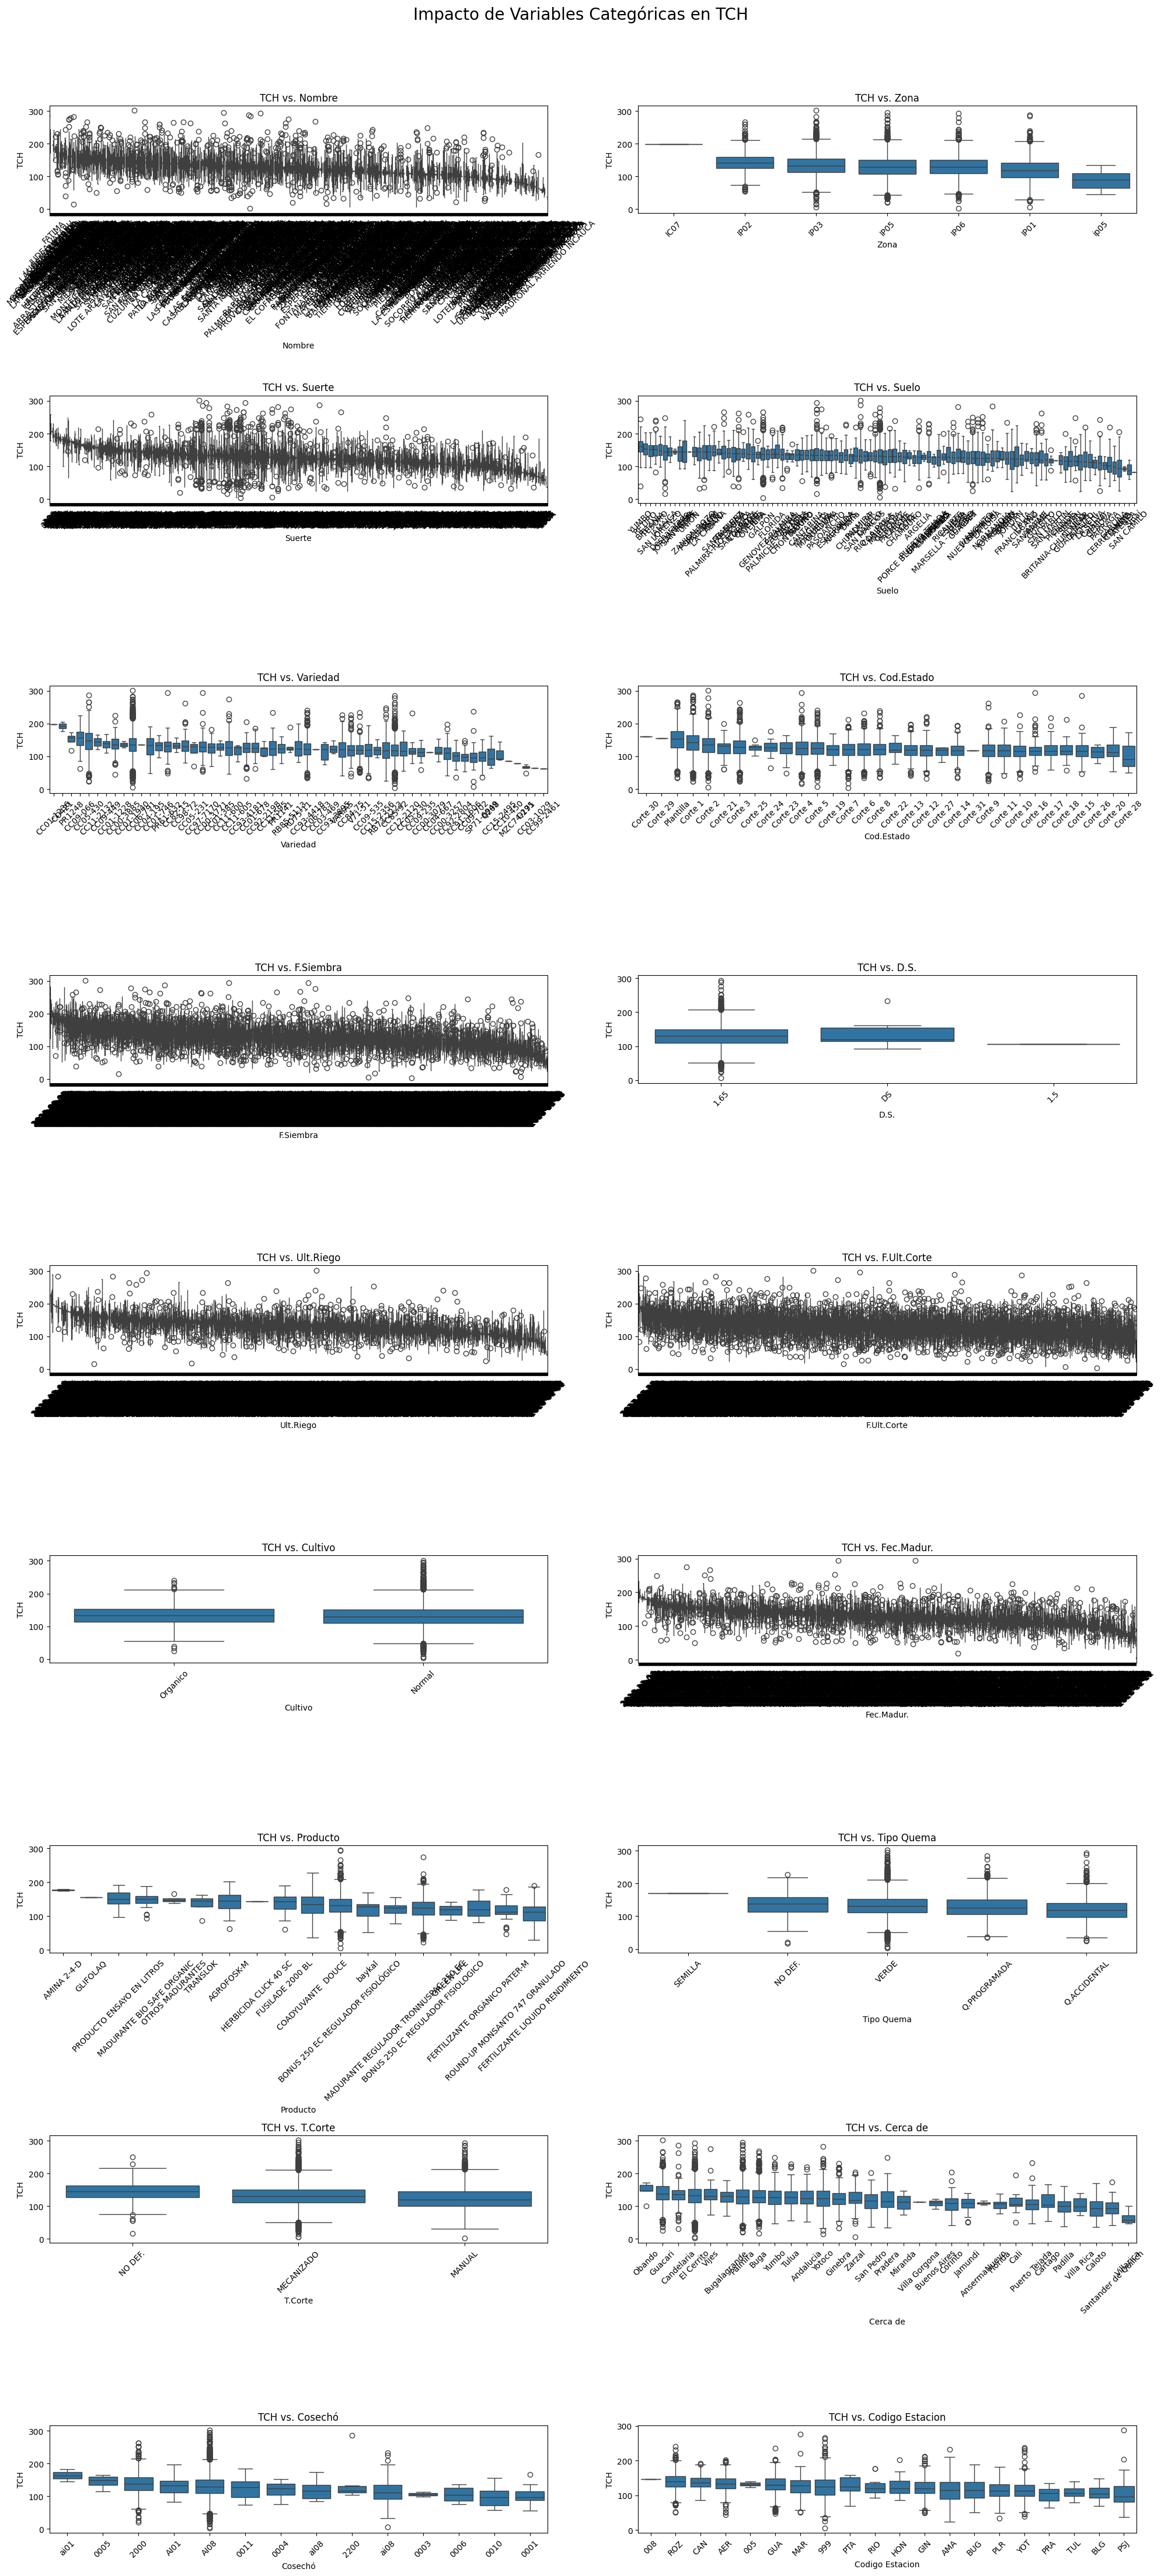

In [27]:
import math

# Número de variables categóricas
n = len(categorical_features)

# Definir número de columnas (ej. 2 o 3 según prefieras)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
fig.suptitle('Impacto de Variables Categóricas en TCH', fontsize=20)

# Asegurar que axes sea 2D
axes = axes.flatten()

# Para TCH
for i, feature in enumerate(categorical_features):
    order = df.groupby(feature)['TCH'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feature, y='TCH', ax=axes[i], order=order)
    axes[i].set_title(f'TCH vs. {feature}')
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar ejes vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

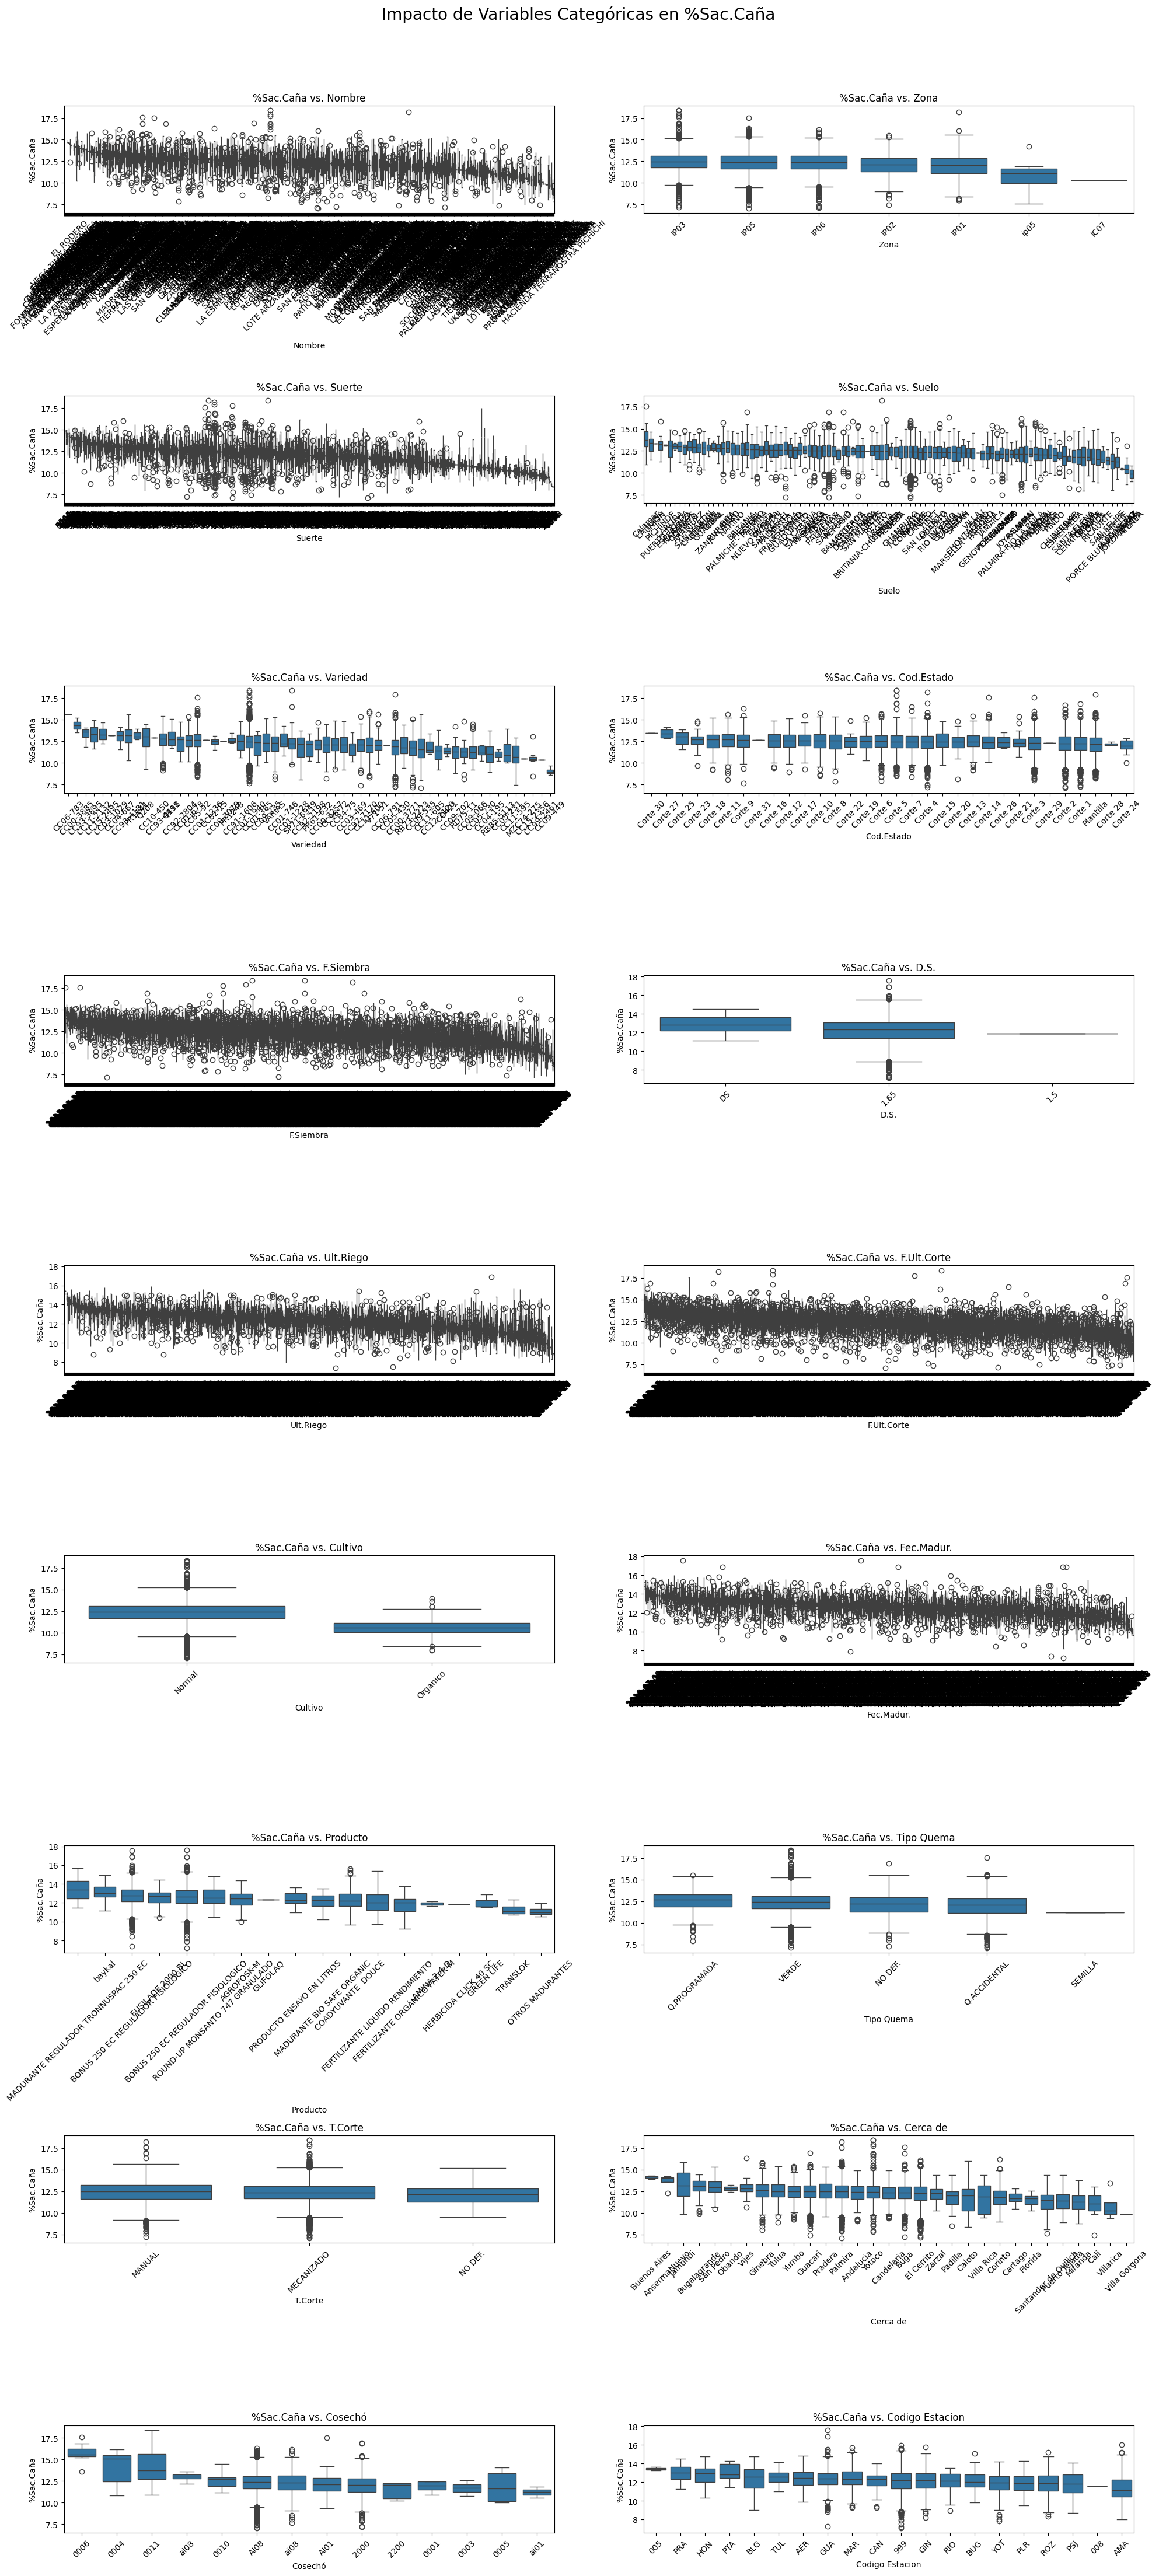

In [28]:
# Para %Sac.Caña
import math

# Número de variables categóricas
n = len(categorical_features)

# Definir número de columnas (ej. 2, puedes poner 3 si quieres más compacto)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
fig.suptitle('Impacto de Variables Categóricas en %Sac.Caña', fontsize=20)

# Asegurar que axes siempre sea 1D
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    order = df.groupby(feature)['%Sac.Caña'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feature, y='%Sac.Caña', ax=axes[i], order=order)
    axes[i].set_title(f'%Sac.Caña vs. {feature}')
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Variedad: Ciertas variedades de caña muestran medianas de TCH y %Sac.Caña claramente distintas, lo que la convierte en una variable predictiva muy prometedora.

Suelo: El tipo de suelo tiene un impacto visible tanto en la productividad como en la calidad. Algunos suelos consistentemente superan a otros.

Tenencia y Tipo de Corte: Estas variables también muestran diferencias en las distribuciones de las variables objetivo, aunque menos pronunciadas que la variedad y el suelo.

# Selección Estratégica de Características

## Exclusiones 

* Identificadores únicos: Hacienda, Nombre, Suerte. Estas columnas no generalizan y causarían sobreajuste.
* Fuga de Datos (Data Leakage): Ton.Azucar, Rdto, TAH, TAHM, TonUltCorte. Estas son calculadas después de la cosecha y no estarán disponibles al momento de hacer una predicción. Incluirlas daría resultados artificialmente perfectos.
* Redundancia y Metadatos: Cod.Estado # (redundante con Cod.Estado), Codigo Estacion (metadato sin valor predictivo directo).


In [29]:
for item in ['Nombre', 'Zona', 'Suerte']:
    categorical_features.remove(item)

categorical_features

['Suelo',
 'Variedad',
 'Cod.Estado',
 'F.Siembra',
 'D.S.',
 'Ult.Riego',
 'F.Ult.Corte',
 'Cultivo',
 'Fec.Madur.',
 'Producto',
 'Tipo Quema',
 'T.Corte',
 'Cerca de',
 'Cosechó',
 'Codigo Estacion']

In [30]:
date_cols = [col for col in categorical_features if 'fec' in col.lower() or 'f.' in col.lower() or 'ult.r' in col.lower()]
date_cols

['F.Siembra', 'Ult.Riego', 'F.Ult.Corte', 'Fec.Madur.']

In [31]:
df[date_cols]

,F.Siembra,Ult.Riego,F.Ult.Corte,Fec.Madur.
0,2010-08-20,NaT,2017-01-02,2016-11-04
1,2011-01-27,NaT,2017-01-02,NaT
2,2011-10-25,2016-09-17,2017-01-02,2016-11-04
3,2014-03-08,NaT,2017-01-02,NaT
4,2013-01-10,NaT,2017-01-02,NaT
...,...,...,...,...
20970,2018-09-06,2024-05-15,2024-06-30,2024-04-29
20971,2015-08-03,2024-04-19,2024-06-30,2024-04-05
20972,2018-09-06,2024-05-15,2024-06-30,2024-04-29
20973,2019-12-31,2024-04-17,2024-06-30,2024-05-30


In [32]:
# 2. Convertir columnas a formato datetime (muy importante)
# El argumento 'coerce' convierte fechas inválidas en NaT (Not a Time)
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(df[date_cols].info())
print(df[date_cols].head())


<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   F.Siembra    20578 non-null  datetime64[ns]
 1   Ult.Riego    8154 non-null   datetime64[ns]
 2   F.Ult.Corte  20578 non-null  datetime64[ns]
 3   Fec.Madur.   11162 non-null  datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 803.8 KB
None
   F.Siembra  Ult.Riego F.Ult.Corte Fec.Madur.
0 2010-08-20        NaT  2017-01-02 2016-11-04
1 2011-01-27        NaT  2017-01-02        NaT
2 2011-10-25 2016-09-17  2017-01-02 2016-11-04
3 2014-03-08        NaT  2017-01-02        NaT
4 2013-01-10        NaT  2017-01-02        NaT


In [33]:
# 3. ESTRATEGIA Descomposición de Fechas
# Extraemos el mes y el año de la fecha de siembra y último corte
df['Mes_Siembra'] = df['F.Siembra'].dt.month
df['Año_Siembra'] = df['F.Siembra'].dt.year

df['Mes_Ult_Corte'] = df['F.Ult.Corte'].dt.month
df['Año_Ult_Corte'] = df['F.Ult.Corte'].dt.year

df['Mes_Madur'] = df['Fec.Madur.'].dt.month
df['Año_Madur'] = df['Fec.Madur.'].dt.year

df['Mes_Riego'] = df['Ult.Riego'].dt.month
df['Año_Riego'] = df['Ult.Riego'].dt.year

In [34]:
# 5. Visualizar las nuevas características creadas
# Seleccionamos las columnas originales y las nuevas para ver el resultado
new_features_df = df[date_cols + [
    'Mes_Siembra', 
    'Año_Siembra', 
    'Mes_Ult_Corte', 
    'Año_Ult_Corte', 
    'Mes_Madur', 
    'Año_Madur',
    'Mes_Riego', 
    'Año_Riego', 
    ]]

print("DataFrame con las nuevas características de fecha:")
print(new_features_df.head())

DataFrame con las nuevas características de fecha:
   F.Siembra  Ult.Riego F.Ult.Corte Fec.Madur.  Mes_Siembra  Año_Siembra  \
0 2010-08-20        NaT  2017-01-02 2016-11-04            8         2010   
1 2011-01-27        NaT  2017-01-02        NaT            1         2011   
2 2011-10-25 2016-09-17  2017-01-02 2016-11-04           10         2011   
3 2014-03-08        NaT  2017-01-02        NaT            3         2014   
4 2013-01-10        NaT  2017-01-02        NaT            1         2013   

   Mes_Ult_Corte  Año_Ult_Corte  Mes_Madur  Año_Madur  Mes_Riego  Año_Riego  
0              1           2017       11.0     2016.0        NaN        NaN  
1              1           2017        NaN        NaN        NaN        NaN  
2              1           2017       11.0     2016.0        9.0     2016.0  
3              1           2017        NaN        NaN        NaN        NaN  
4              1           2017        NaN        NaN        NaN        NaN  


In [35]:
for col in date_cols:
    categorical_features.remove(col)
categorical_features

['Suelo',
 'Variedad',
 'Cod.Estado',
 'D.S.',
 'Cultivo',
 'Producto',
 'Tipo Quema',
 'T.Corte',
 'Cerca de',
 'Cosechó',
 'Codigo Estacion']

In [36]:
for col in [
    'Mes_Siembra', 
    'Año_Siembra', 
    'Mes_Ult_Corte', 
    'Año_Ult_Corte', 
    'Mes_Madur', 
    'Año_Madur',
    'Mes_Riego',
    'Año_Riego'
    ]:
    categorical_features.append(col)
    
categorical_features

['Suelo',
 'Variedad',
 'Cod.Estado',
 'D.S.',
 'Cultivo',
 'Producto',
 'Tipo Quema',
 'T.Corte',
 'Cerca de',
 'Cosechó',
 'Codigo Estacion',
 'Mes_Siembra',
 'Año_Siembra',
 'Mes_Ult_Corte',
 'Año_Ult_Corte',
 'Mes_Madur',
 'Año_Madur',
 'Mes_Riego',
 'Año_Riego']

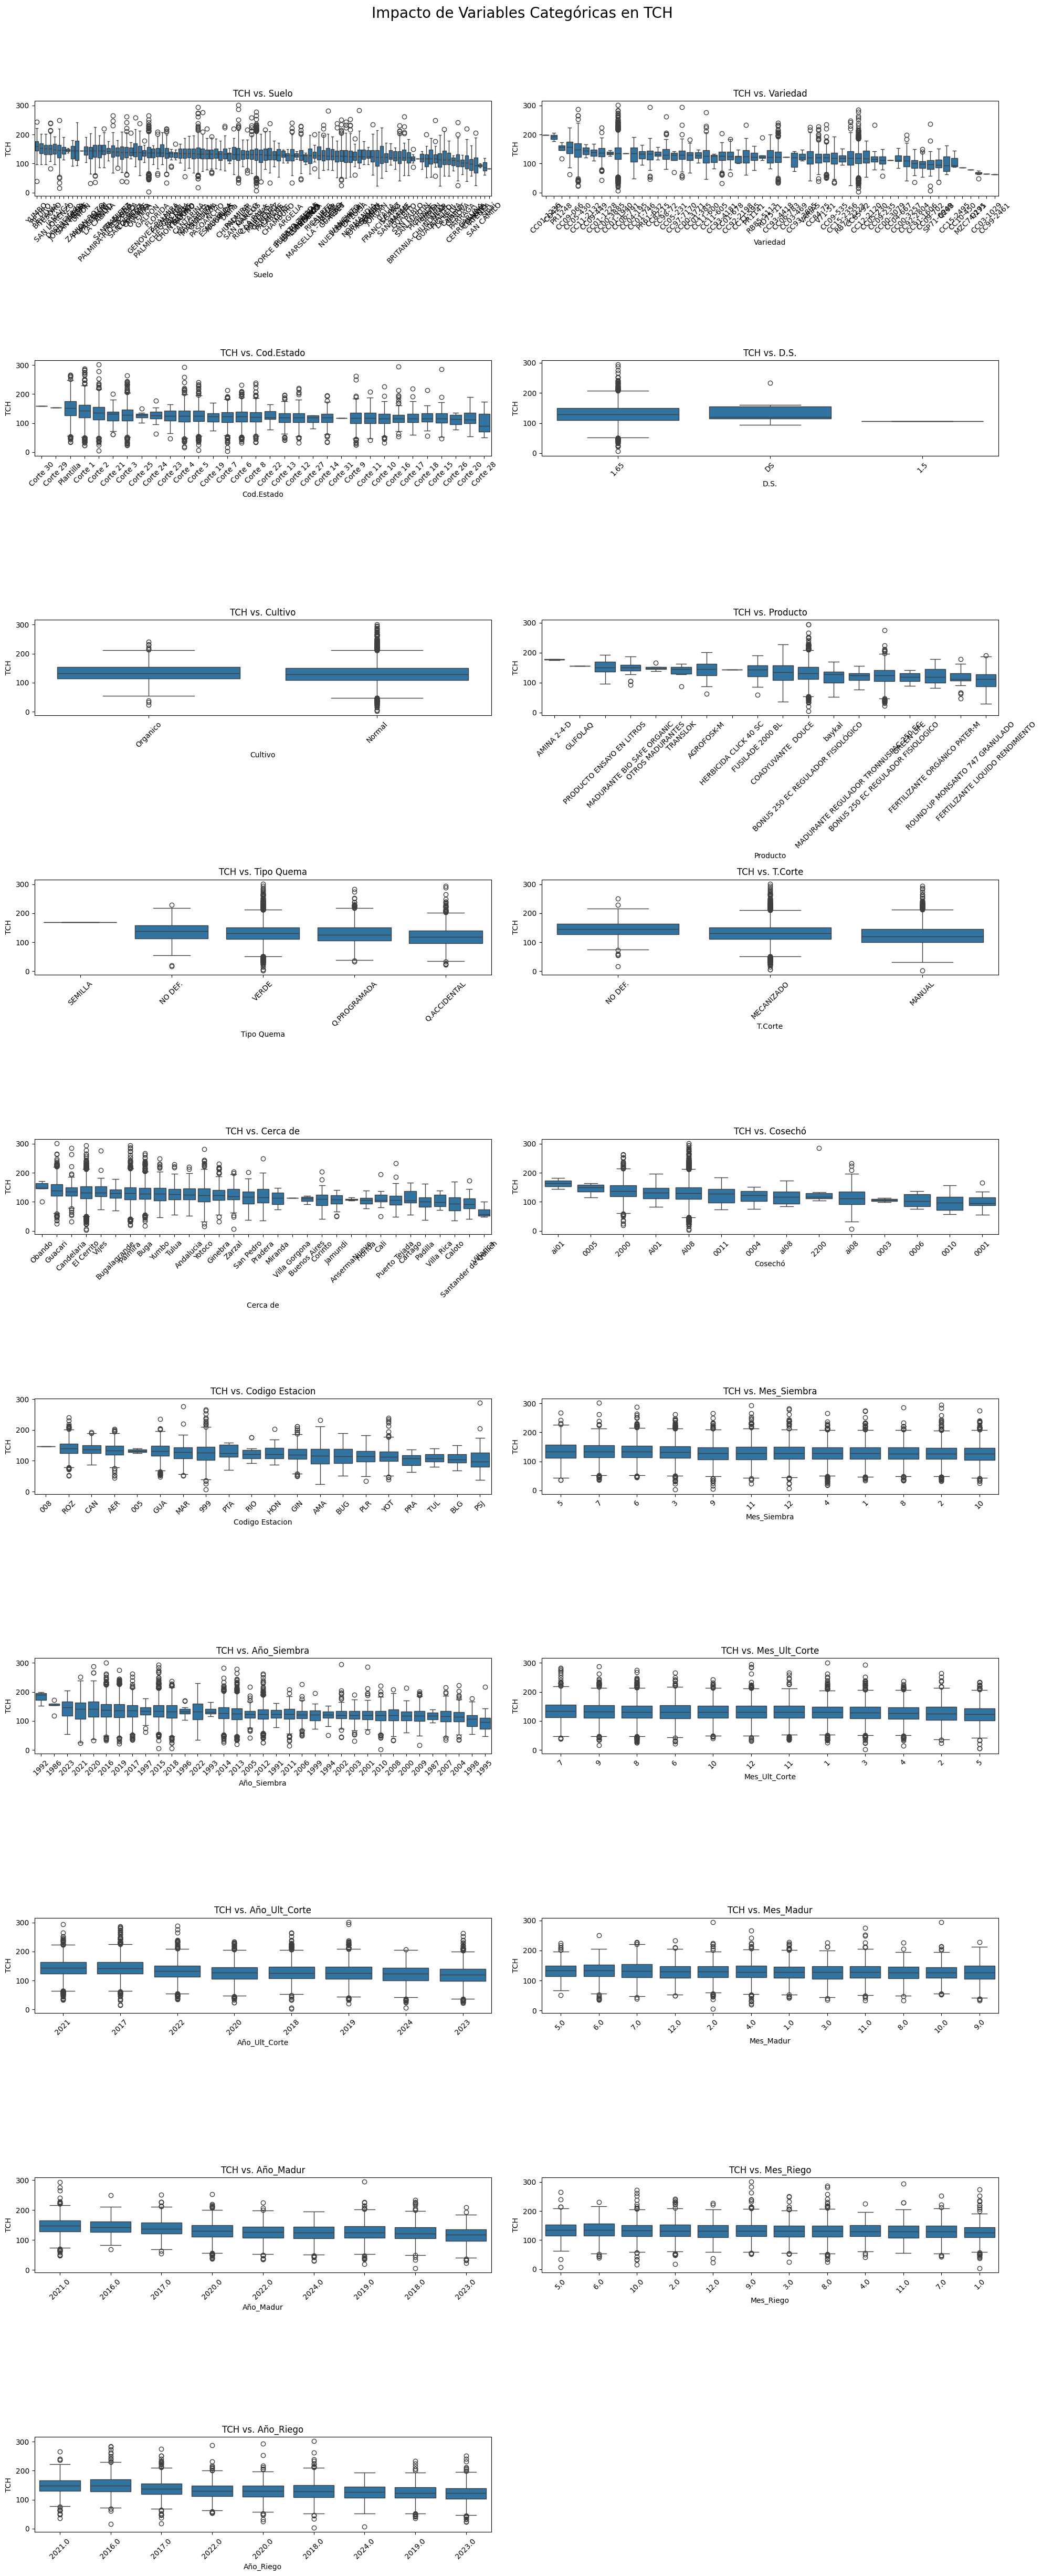

In [37]:
# Número de variables categóricas
n = len(categorical_features)

# Definir número de columnas (ej. 2 o 3 según prefieras)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
fig.suptitle('Impacto de Variables Categóricas en TCH', fontsize=20)

# Asegurar que axes sea 2D
axes = axes.flatten()

# Para TCH
for i, feature in enumerate(categorical_features):
    order = df.groupby(feature)['TCH'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feature, y='TCH', ax=axes[i], order=order)
    axes[i].set_title(f'TCH vs. {feature}')
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar ejes vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [38]:
# 6. Limpieza final
# Ahora podemos eliminar las columnas de fecha originales antes de entrenar el modelo
df.drop(columns=date_cols, inplace=True)

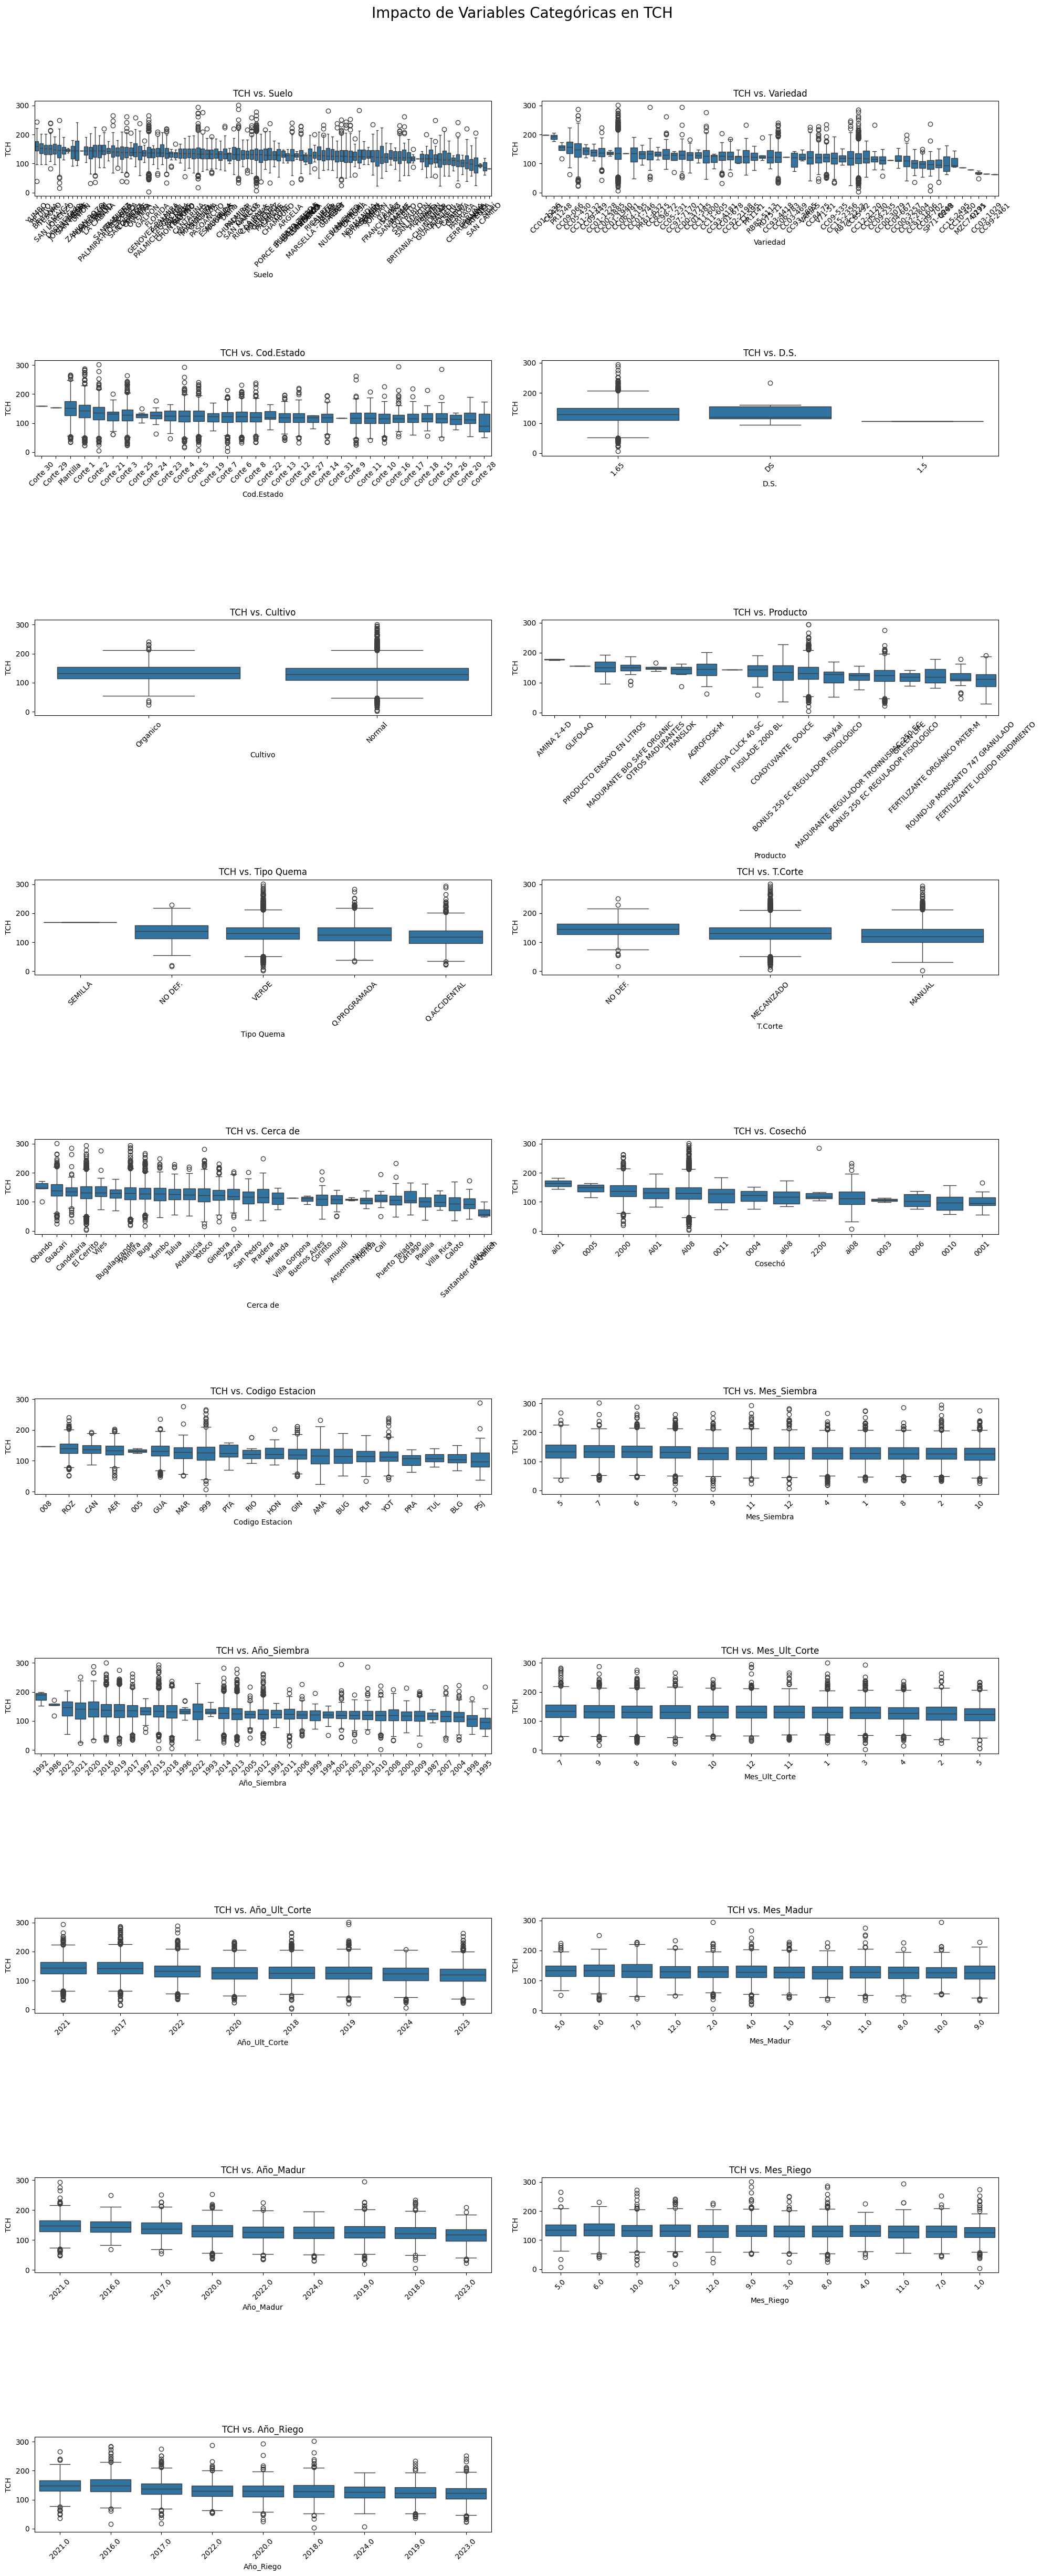

In [39]:
# Número de variables categóricas
n = len(categorical_features)

# Definir número de columnas (ej. 2 o 3 según prefieras)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
fig.suptitle('Impacto de Variables Categóricas en TCH', fontsize=20)

# Asegurar que axes sea 2D
axes = axes.flatten()

# Para TCH
for i, feature in enumerate(categorical_features):
    order = df.groupby(feature)['TCH'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feature, y='TCH', ax=axes[i], order=order)
    axes[i].set_title(f'TCH vs. {feature}')
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar ejes vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Ahora analizaremos en profundidad la variable Variedad, ya que es una de las características más importantes en agronomía, y tratarla correctamente puede mejorar significativamente el rendimiento del modelo.

Siguiendo nuestro enfoque, primero la analizaremos a fondo y luego definiremos la mejor estrategia para incluirla en el modelo.

In [40]:
# Contar el número de variedades únicas (Cardinalidad)
num_variedades = df['Variedad'].nunique()
print(f"Número total de variedades únicas de caña: {num_variedades}")

Número total de variedades únicas de caña: 57


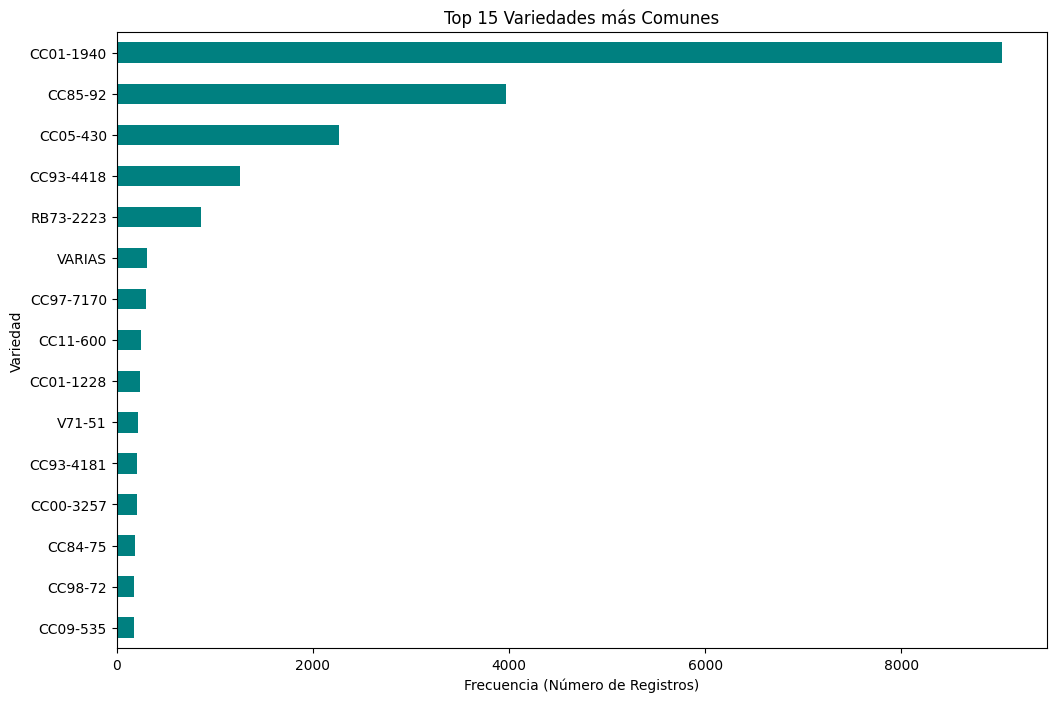

In [41]:
# Ver la frecuencia de las 15 variedades más comunes
plt.figure(figsize=(12, 8))
df['Variedad'].value_counts().nlargest(15).plot(kind='barh', color='teal')
plt.title('Top 15 Variedades más Comunes')
plt.xlabel('Frecuencia (Número de Registros)')
plt.gca().invert_yaxis() # Poner la más común arriba
plt.show()

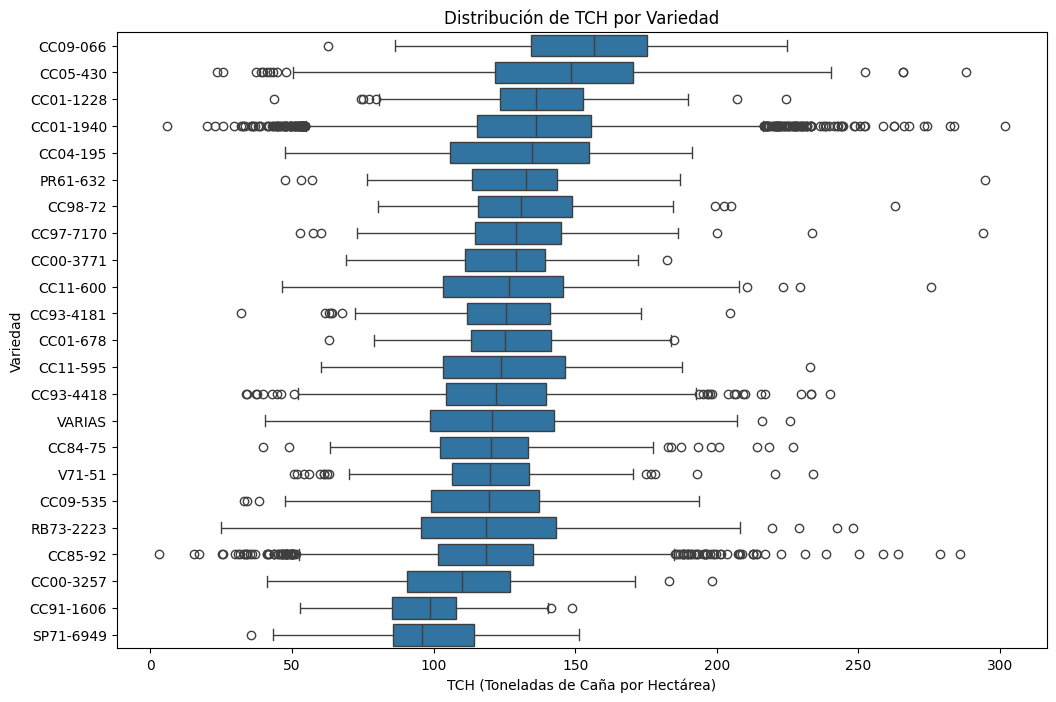

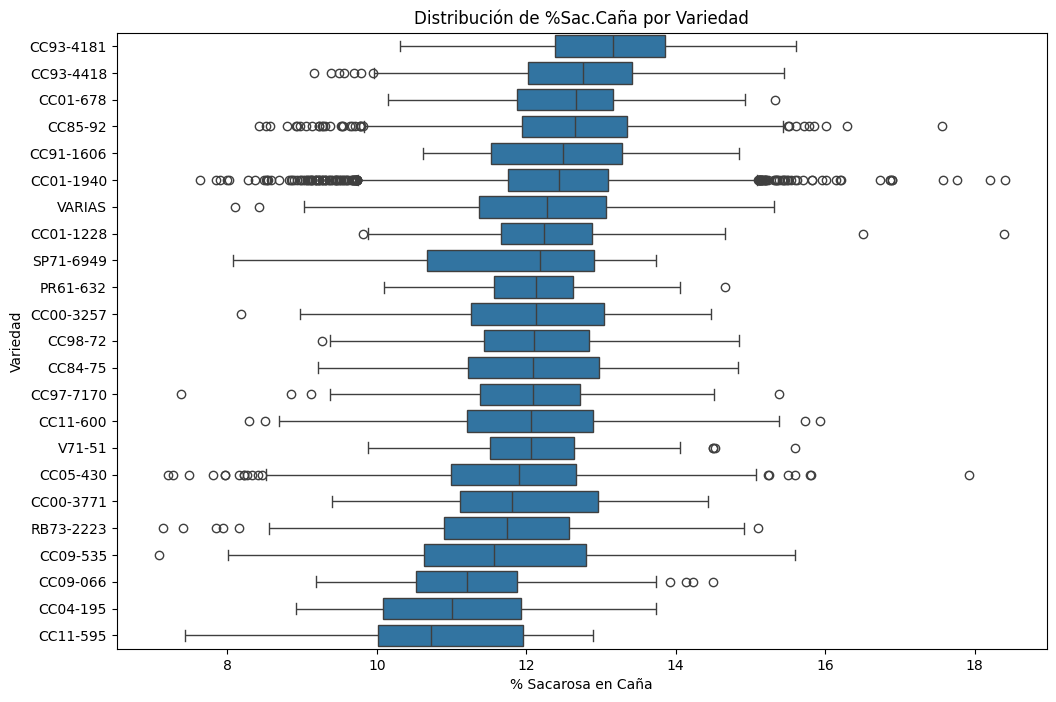

In [42]:
# Agrupar por variedad y calcular la mediana de las variables objetivo
impacto_variedad = df.groupby('Variedad').agg(
    TCH_Mediana=pd.NamedAgg(column='TCH', aggfunc='median'),
    Sac_Caña_Mediana=pd.NamedAgg(column='%Sac.Caña', aggfunc='median'),
    Frecuencia=pd.NamedAgg(column='Variedad', aggfunc='count')
).reset_index()

# Filtrar variedades con poca frecuencia para un análisis más robusto
impacto_variedad_filtrado = impacto_variedad[impacto_variedad['Frecuencia'] > 30]

# Visualizar el impacto en TCH
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[df['Variedad'].isin(impacto_variedad_filtrado['Variedad'].unique())], 
            x='TCH', 
            y='Variedad', 
            order=impacto_variedad_filtrado.sort_values('TCH_Mediana', ascending=False)['Variedad'])
plt.title('Distribución de TCH por Variedad')
plt.xlabel('TCH (Toneladas de Caña por Hectárea)')
plt.show()

# Visualizar el impacto en %Sac.Caña
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[df['Variedad'].isin(impacto_variedad_filtrado['Variedad'].unique())], 
            x='%Sac.Caña', 
            y='Variedad', 
            order=impacto_variedad_filtrado.sort_values('Sac_Caña_Mediana', ascending=False)['Variedad'])
plt.title('Distribución de %Sac.Caña por Variedad')
plt.xlabel('% Sacarosa en Caña')
plt.show()

Esta variable es importante ya que nos proporcionan datos interesantes

Alto Rendimiento vs. Alta Calidad: Los gráficos de cajas revelan un patrón crucial: las variedades con el TCH más alto no son necesariamente las que tienen el mayor % de sacarosa, ya que una variedad puede producir mucha caña (alto TCH) pero con bajo contenido de azúcar, mientras que otra puede producir menos caña pero de muchísima más calidad.

Esta visualización es muy importante ya que para la toma de decisiones. Permite identificar qué variedades son "todo terreno o perfectas en cualquier ecosistema" las cuáles son "de volumen" y cuáles son "de calidad".

### Estrategia de Codificación para el Modelo para variedad

Dado que Variedad es una variable categórica sin un orden inherente, One-Hot Encoding (la técnica usada en nuestro pipeline) es la correcta. Sin embargo, debido a la alta cardinalidad y la presencia de variedades raras, podemos optimizarla.

Optimización: Agrupar Categorías Raras
Las variedades que aparecen muy pocas veces (ej: menos de 10 o 20 veces) no proporcionan suficiente información para que el modelo aprenda un patrón robusto. Además, crean muchas columnas después del One-Hot Encoding, lo que puede encontrar la importancia de las variables más fuertes.

La solución es agrupar todas estas variedades raras en una única categoría, por ejemplo, 'OTRA'

In [43]:
frecuencia_variedades = df['Variedad'].value_counts()
variedades_comunes = frecuencia_variedades[frecuencia_variedades > 500].index.tolist()
variedades_comunes

['CC01-1940', 'CC85-92', 'CC05-430', 'CC93-4418', 'RB73-2223']

In [44]:
# 2. Reemplazar las variedades raras por la categoría 'OTRA'
# Usamos .loc para modificar el DataFrame de forma segura
df['Variedad'] = df['Variedad'].copy() # Crear una nueva columna para no perder la original
df.loc[~df['Variedad'].isin(variedades_comunes), 'Variedad'] = 'OTRA'


In [45]:
# 3. Comprobar el resultado
print("\nConteo de variedades después de agrupar las raras:")
print(df['Variedad'].value_counts())


Conteo de variedades después de agrupar las raras:
Variedad
CC01-1940    9029
CC85-92      3974
OTRA         3188
CC05-430     2270
CC93-4418    1255
RB73-2223     862
Name: count, dtype: int64


## Por que el producto debe ir 

Sí, es extremadamente importante.

La variable Producto (el madurante aplicado) captura una de las intervenciones agronómicas más directas y deliberadas que se realizan sobre el cultivo con el objetivo específico de alterar la calidad de la caña (%Sac.Caña).

Ignorar esta variable o tratarla incorrectamente significaría descartar una de las pistas más claras sobre el rendimiento esperado de la cosecha.

### ¿Por Qué es tan Crucial?
Causalidad Directa: A diferencia de variables como el clima o el suelo, la aplicación de un madurante es una decisión humana intencionada. El propósito de un madurante es acelerar la concentración de sacarosa en la planta, a menudo a expensas de un mayor crecimiento en biomasa (TCH). El modelo debe conocer si se tomó esta decisión para interpretar correctamente los resultados.

Explicación de la Variabilidad: Si el modelo ve una suerte con un %Sac.Caña inusualmente alto para su edad o variedad, pero no sabe que se le aplicó un madurante, interpretará ese resultado como "ruido" o un valor atípico. Al incluir la variable Se_Aplico_Madurante, le damos al modelo la pieza clave que explica esa variabilidad.

Valor Estratégico para el Negocio: Un modelo que entiende el efecto de los madurantes puede ser usado para responder preguntas de negocio críticas:

¿Realmente vale la pena el costo de aplicar un madurante?

¿En qué condiciones (tipo de suelo, variedad, clima) es más efectivo aplicar un madurante?

¿Podemos predecir el aumento exacto en %Sac.Caña para justificar la inversión?

### Resumen: La Importancia en una Frase
Tratar correctamente la variable Producto es importante porque transforma al modelo de ser simplemente descriptivo a ser prescriptivo, permitiéndole entender el impacto de una decisión clave y ayudando al Ingenio Providencia a optimizar sus intervenciones agronómicas.

La estrategia que discutimos de crear la variable binaria Se_Aplico_Madurante es la forma más robusta y efectiva de inyectar esta información crucial en tu modelo.

In [ ]:
# Convertir la variable objetivo 'Producto' a numérica (1 si tiene valor, 0 si es nulo)
df['Producto'] = df['Producto'].notna().astype(int)

In [ ]:
# Verificar la conversión 
for col in ['Suelo', 
  'Cod.Estado',
  'D.S.',
  'Cerca de',
  'Cosechó',
  'Codigo Estacion',
  ]:
    categorical_features.remove(col)

categorical_features

['Variedad',
 'Cultivo',
 'Producto',
 'Tipo Quema',
 'T.Corte',
 'Mes_Siembra',
 'Año_Siembra',
 'Mes_Ult_Corte',
 'Año_Ult_Corte',
 'Mes_Madur',
 'Año_Madur',
 'Mes_Riego',
 'Año_Riego']

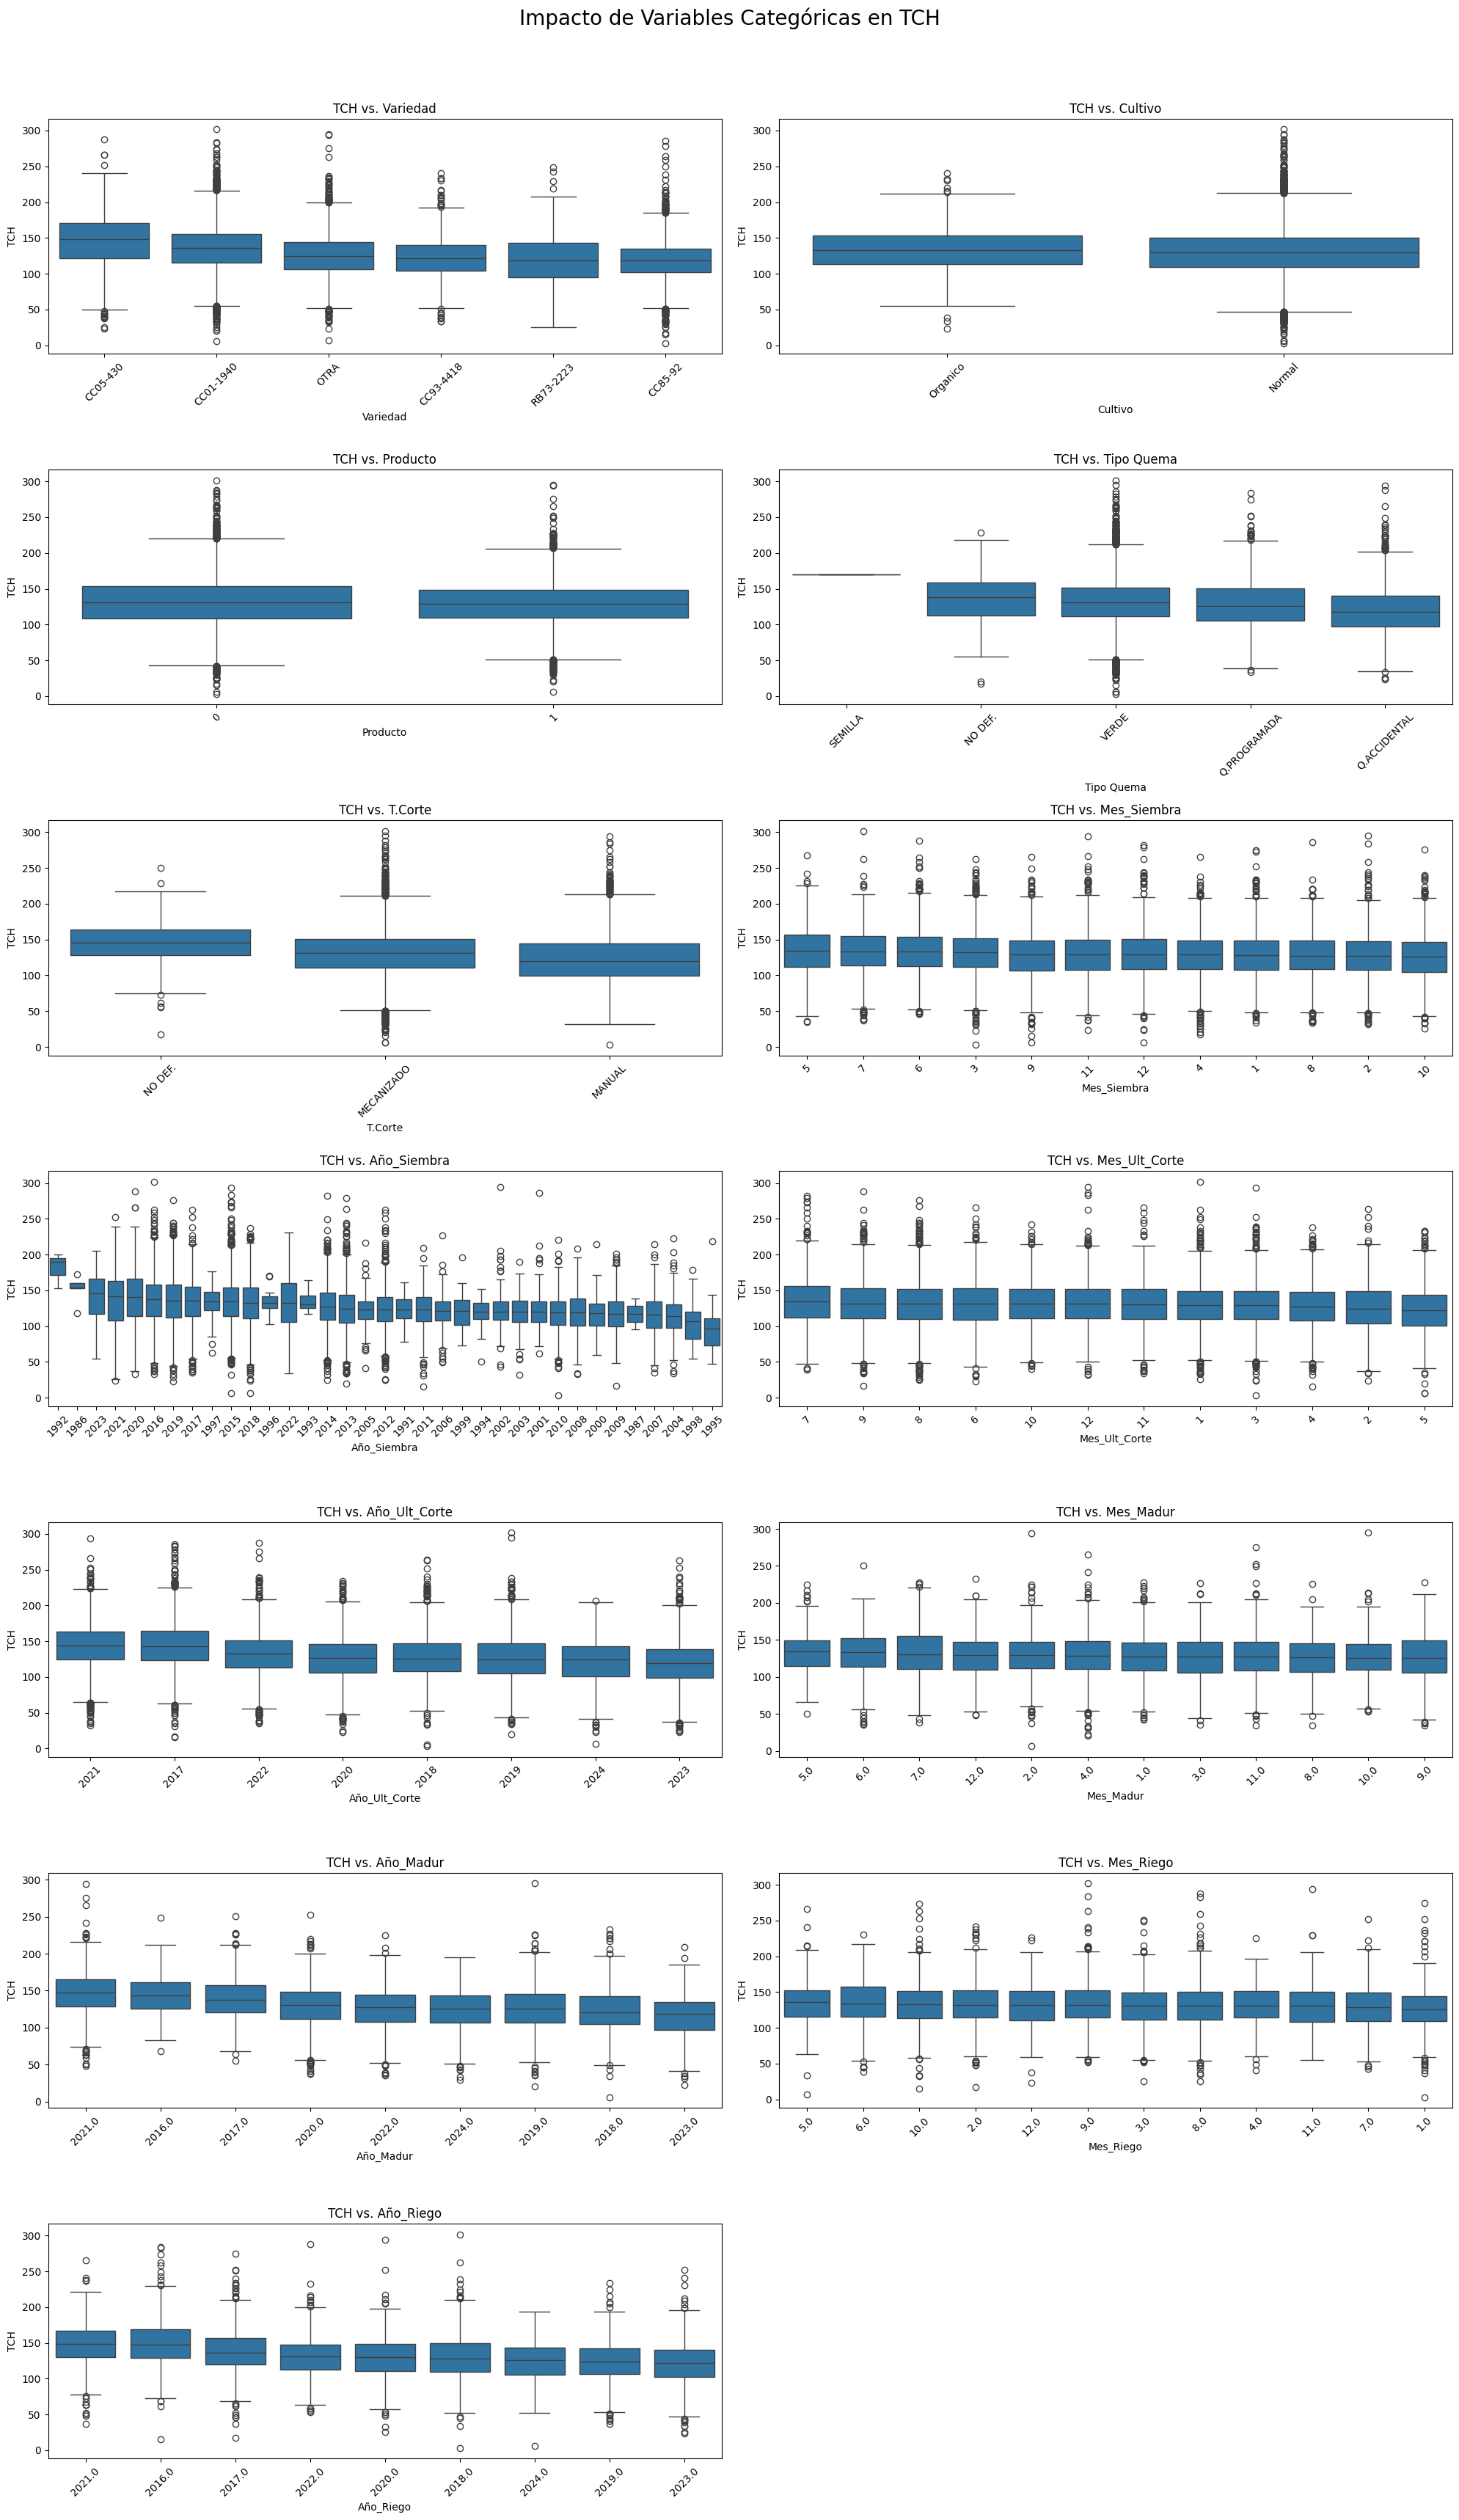

In [48]:
# Número de variables categóricas
n = len(categorical_features)

# Definir número de columnas (ej. 2 o 3 según prefieras)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
fig.suptitle('Impacto de Variables Categóricas en TCH', fontsize=20)

# Asegurar que axes sea 2D
axes = axes.flatten()

# Para TCH
for i, feature in enumerate(categorical_features):
    order = df.groupby(feature)['TCH'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feature, y='TCH', ax=axes[i], order=order)
    axes[i].set_title(f'TCH vs. {feature}')
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar ejes vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [83]:
df[categorical_features]

,Variedad,Cultivo,Producto,Tipo Quema,T.Corte,Mes_Siembra,Año_Siembra,Mes_Ult_Corte,Año_Ult_Corte,Mes_Madur,Año_Madur,Mes_Riego,Año_Riego
0,CC85-92,Normal,1,VERDE,MECANIZADO,8,2010,1,2017,11.0,2016.0,NaN,NaN
1,CC85-92,Normal,0,Q.ACCIDENTAL,MANUAL,1,2011,1,2017,NaN,NaN,NaN,NaN
2,OTRA,Normal,1,VERDE,MECANIZADO,10,2011,1,2017,11.0,2016.0,9.0,2016.0
3,CC01-1940,Normal,0,Q.ACCIDENTAL,MANUAL,3,2014,1,2017,NaN,NaN,NaN,NaN
4,RB73-2223,Normal,0,Q.ACCIDENTAL,MANUAL,1,2013,1,2017,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20970,CC01-1940,Normal,1,VERDE,MECANIZADO,9,2018,6,2024,4.0,2024.0,5.0,2024.0
20971,CC01-1940,Normal,1,VERDE,MECANIZADO,8,2015,6,2024,4.0,2024.0,4.0,2024.0
20972,CC01-1940,Normal,1,VERDE,MECANIZADO,9,2018,6,2024,4.0,2024.0,5.0,2024.0
20973,CC05-430,Normal,1,VERDE,MECANIZADO,12,2019,6,2024,5.0,2024.0,4.0,2024.0


In [84]:
df[categorical_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Variedad       20578 non-null  object 
 1   Cultivo        20576 non-null  object 
 2   Producto       20578 non-null  int64  
 3   Tipo Quema     20578 non-null  object 
 4   T.Corte        20578 non-null  object 
 5   Mes_Siembra    20578 non-null  int32  
 6   Año_Siembra    20578 non-null  int32  
 7   Mes_Ult_Corte  20578 non-null  int32  
 8   Año_Ult_Corte  20578 non-null  int32  
 9   Mes_Madur      11162 non-null  float64
 10  Año_Madur      11162 non-null  float64
 11  Mes_Riego      8154 non-null   float64
 12  Año_Riego      8154 non-null   float64
dtypes: float64(4), int32(4), int64(1), object(4)
memory usage: 1.9+ MB


Variables con Pocos Nulos: Cultivo
Observación: Le faltan solo 2 datos (20576 non-null).

Significado: Son simples errores de registro.

Acción Recomendada: Imputar con la moda (el valor más frecuente).

Justificación: Al ser tan pocos los datos faltantes, rellenarlos con el valor más común es una solución segura, rápida y que no introduce ningún sesgo en el modelo.

In [ ]:
# Imputar nulos en variables categóricas con la moda
columnas_a_imputar_moda = ['Cultivo']
for col in columnas_a_imputar_moda:
    if col in df.columns:
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(f"Imputados los nulos de la columna '{col}' con la moda ('{moda}')")

Imputados los nulos de la columna 'Cultivo' con la moda ('Normal')


C:\Users\Pipicano\AppData\Local\Temp\ipykernel_8888\268647058.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(moda, inplace=True)


Variables de Maduración: Mes_Madur y Año_Madur
Observación: Tienen un 45% de datos faltantes (11162 / 20578).

Significado: Un valor nulo aquí significa que no se aplicó un producto madurante.

Acción Recomendada: Eliminar las columnas Mes_Madur y Año_Madur.

Justificación: Ya hemos capturado la información más importante de este proceso en la variable binaria Se_Aplico_Madurante. Esta variable (con un 1 o 0) es mucho más fuerte y limpia que intentar imputar casi la mitad de los datos en Mes_Madur. Forzar una imputación aquí añadiría más ruido que señal. Nos quedamos con la variable binaria que es más robusta.

In [88]:
print([col for col in df.columns])

['Período', 'Hacienda', 'Nombre', 'Zona', 'Tenencia', 'Suerte', 'Suelo', 'Area Neta', 'Dist Km', 'Variedad', 'Cod.Estado #', 'Cod.Estado', 'D.S.', 'Edad Ult Cos', 'Destino 1=Semilla', 'Cod. T.Cultivo', 'Cultivo', 'Producto', 'Dosis Madurante', 'Semanas mad.', 'TonUltCorte', 'TCH', 'TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', 'Sac.Caña Precosecha', 'Edad.Precosecha', '%Sac.Caña', '%Sac.Muestreadora', '%ATR', 'KATRHM', '%Fibra Caña', '%AR Jugo', '%ME Min', '%ME Veg', '%ME Tot', 'Brix', 'Pureza', 'Vejez', 'Tipo Quema', 'T.Corte', 'Cerca de', 'Cosechó', 'Num.Riegos', 'M3 Riego', 'DDUlt.Riego', 'Lluvias (2 Meses Ant.)', 'Lluvias Ciclo', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC', '%Infest.Diatrea', 'Fosfato Jugo', 'Fert.Nitrogen.', 'Urea 46%', 'MEZ', 'Boro Granul.', 'MicroZinc', 'NITO_XTEND', 'Sul.Amonio', 'NITRAX-S', 'Vinaza', 'Codigo Estacion', 'Temp. Media 0-3', 'Temp. Media Ciclo', 'Temp Max Ciclo', 'Temp Min Ciclo', 'Humedad Rel Media 0-3 ', 'Humedad 

In [ ]:
df_maduro = df.copy()

# 1. Crear variables binarias para el análisis
# 'Fecha_Madur_Existe' será 1 si Mes_Madur no es nulo, y 0 si es nulo.
df_maduro['Fecha_Madur_Existe'] = df_maduro['Mes_Madur'].notna().astype(int)

# 'Producto_Aplicado' será 1 si Producto no es nulo, y 0 si es nulo.
df_maduro['Producto_Aplicado'] = df_maduro['Producto'].notna().astype(int)

# 2. Crear la tabla de contingencia
contingency_table = pd.crosstab(
    df_maduro['Fecha_Madur_Existe'],
    df_maduro['Producto_Aplicado']
)

print("--- Tabla de Contingencia ---")
print(contingency_table)


--- Tabla de Contingencia ---
Producto_Aplicado       1
Fecha_Madur_Existe       
0                    9416
1                   11162


Esta tabla es la muy importente ya que nos explica que hay una relacion demasiada fuerte

Hay 11,162 casos donde existe una fecha de maduración (Fecha_Madur_Existe = 1) y en el 100% de ellos, se aplicó un producto (Producto_Aplicado = 1).

Hay 9,416 casos donde NO existe una fecha de maduración (Fecha_Madur_Existe = 0) y en el 100% de ellos, NO se aplicó un producto (Producto_Aplicado = 0).

Estadísticamente, las dos variables son perfectamente colineales. Conocer el estado de una (existe o no existe) nos permite predecir el estado de la otra con un 100% de certeza

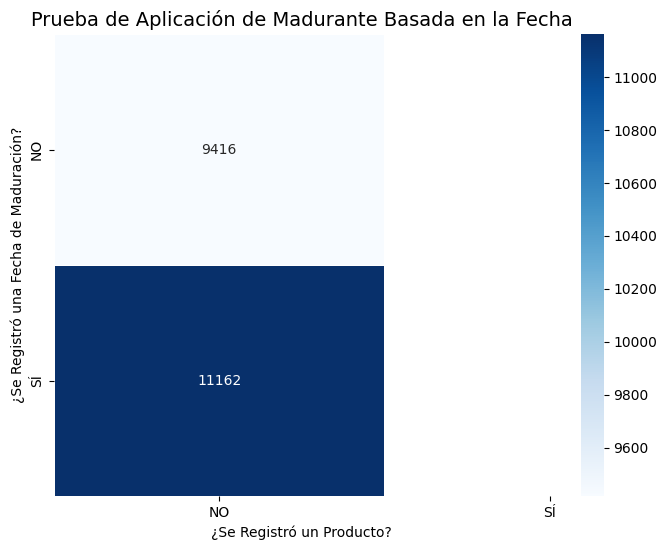

In [90]:
# Visualizar la tabla con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues', linewidths=.5)
plt.title('Prueba de Aplicación de Madurante Basada en la Fecha', fontsize=14)
plt.xlabel('¿Se Registró un Producto?')
plt.ylabel('¿Se Registró una Fecha de Maduración?')
plt.xticks([0.5, 1.5], ['NO', 'SÍ'])
plt.yticks([0.5, 1.5], ['NO', 'SÍ'])
plt.show()

El gráfico muestra una diagonal perfecta y absoluta. Todo el peso de los datos recae en las celdas (NO, NO) y (SÍ, SÍ). Las otras dos celdas están vacías.

Esto demuestra visualmente que la presencia de un dato en Mes_Madur y Año_Madur no es solo un "indicador" de que se aplicó un madurante; es la evidencia directa y concluyente de esa acción.

Conclusión Lógica:
Desde el punto de vista del negocio, es evidente: solo se registra una Fec.Madur. cuando un operario efectivamente aplica un Producto en el campo. Un evento causa el otro.

Dado que hemos probado que la información es idéntica, y que casi la mitad de las filas tienen un nulo en Mes_Madur (representando los casos donde "NO se aplicó"), la decisión más sabia para el modelo es usar una única columna binaria (Se_Aplico_Madurante) que captura esta misma verdad (SÍ/NO) sin tener que lidiar con la imputación masiva de casi 10,000 valores nulos.

Variables de Riego: Mes_Riego y Año_Riego
Observación: Tienen un 60% de datos faltantes (8154 / 20578), lo cual es altísimo.

Significado: Un valor nulo aquí muy probablemente significa que la suerte no recibió riego o no se registró.

Acción Recomendada: Eliminar las columnas Mes_Riego y Año_Riego. En su lugar, nos aseguraremos de que la información sobre el riego esté bien representada por la variable Num.Riegos.

Justificación: Con más del 60% de los datos faltantes, imputar el mes y el año del último riego es muy poco fiable.

In [ ]:
# Imputar nulos en Mes_Riego y Año_Riego con 0 (indicando "sin riego registrado")
df['Mes_Riego'].fillna(0, inplace=True)
df['Año_Riego'].fillna(0, inplace=True)
df['Mes_Riego'] = df['Mes_Riego'].astype(int)
df['Año_Riego'] = df['Año_Riego'].astype(int)

C:\Users\Pipicano\AppData\Local\Temp\ipykernel_8888\2210826706.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Mes_Riego'].fillna(0, inplace=True)
C:\Users\Pipicano\AppData\Local\Temp\ipykernel_8888\2210826706.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [92]:
df[categorical_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Variedad       20578 non-null  object 
 1   Cultivo        20578 non-null  object 
 2   Producto       20578 non-null  int64  
 3   Tipo Quema     20578 non-null  object 
 4   T.Corte        20578 non-null  object 
 5   Mes_Siembra    20578 non-null  int32  
 6   Año_Siembra    20578 non-null  int32  
 7   Mes_Ult_Corte  20578 non-null  int32  
 8   Año_Ult_Corte  20578 non-null  int32  
 9   Mes_Madur      11162 non-null  float64
 10  Año_Madur      11162 non-null  float64
 11  Mes_Riego      20578 non-null  int64  
 12  Año_Riego      20578 non-null  int64  
dtypes: float64(2), int32(4), int64(3), object(4)
memory usage: 1.9+ MB


In [ ]:
# Eliminar las columnas de Mes_Madur y Año_Madur
columnas_a_eliminar = ['Mes_Madur', 'Año_Madur']

df.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

categorical_features = [col for col in categorical_features if col not in columnas_a_eliminar]
categorical_features

['Variedad',
 'Cultivo',
 'Producto',
 'Tipo Quema',
 'T.Corte',
 'Mes_Siembra',
 'Año_Siembra',
 'Mes_Ult_Corte',
 'Año_Ult_Corte',
 'Mes_Riego',
 'Año_Riego']

In [100]:
df[categorical_features]

,Variedad,Cultivo,Producto,Tipo Quema,T.Corte,Mes_Siembra,Año_Siembra,Mes_Ult_Corte,Año_Ult_Corte,Mes_Riego,Año_Riego
0,CC85-92,Normal,1,VERDE,MECANIZADO,8,2010,1,2017,0,0
1,CC85-92,Normal,0,Q.ACCIDENTAL,MANUAL,1,2011,1,2017,0,0
2,OTRA,Normal,1,VERDE,MECANIZADO,10,2011,1,2017,9,2016
3,CC01-1940,Normal,0,Q.ACCIDENTAL,MANUAL,3,2014,1,2017,0,0
4,RB73-2223,Normal,0,Q.ACCIDENTAL,MANUAL,1,2013,1,2017,0,0
...,...,...,...,...,...,...,...,...,...,...,...
20970,CC01-1940,Normal,1,VERDE,MECANIZADO,9,2018,6,2024,5,2024
20971,CC01-1940,Normal,1,VERDE,MECANIZADO,8,2015,6,2024,4,2024
20972,CC01-1940,Normal,1,VERDE,MECANIZADO,9,2018,6,2024,5,2024
20973,CC05-430,Normal,1,VERDE,MECANIZADO,12,2019,6,2024,4,2024


# Trasformacion de variables categoricas

Meses (Mes_Siembra, Mes_Ult_Corte, Mes_Riego)
Decisión: MANTENER COMO CATEGÓRICAS. Deben ser procesadas por el OneHotEncoder.

Para transformar los meses aunque son números (1-12), no tienen una relación de magnitud lineal. El mes 2 (Febrero) no es el doble del mes 1 (Enero). Más importante aún, son cíclicos: el mes 12 (Diciembre) está conceptualmente al lado del mes 1. Si los tratáramos como numéricos, el modelo asumiría erróneamente que están muy lejos. Al tratarlos como categorías, el modelo puede aprender el impacto individual de cada mes, ejemplo las siembras en mayo son especiales, lo cual es la forma correcta de capturar la estacionalidad.

Años (Año_Siembra, Año_Ult_Corte, Año_Riego)
Decisión: MOVER A NUMÉRICAS. Deben ser procesadas por el StandardScaler.

Para transformar los años sí representan una cantidad ordenada y con magnitud. El año 2023 es mayor que 2022, y esta progresión es significativa. Al tratarlos como numéricos, permitimos que el modelo capture tendencias a largo plazo. Por ejemplo, podría aprender que, en general, la productividad ha aumentado 0.5% cada año debido a la mejora tecnológica. Si los tratáramos como categorías, el modelo vería "2022" y "2023" como dos etiquetas completamente no relacionadas, perdiendo la valiosa información de la tendencia temporal.

# imputacion de datos en numericos

In [49]:
numeric_features = []

for col in correlaciones_uso:
    numeric_features.append(col[1])

numeric_features = list(set(numeric_features))
print(numeric_features)
print(len(numeric_features))

['Edad.Precosecha', '%AR Jugo', 'Período', 'Lluvias 0 -3', 'Precipitacion Ciclo', 'Boro Granul.', 'Luvias 9 -FC', 'TCH', 'Edad Ult Cos', '%ME Min', 'Tenencia', 'Area Neta', 'Precipitacion 0_3', 'Humedad Rel Media 0-3 ', 'DDUlt.Riego', 'Lluvias Ciclo', 'Semanas mad.', '%ME Tot', 'Temp Max Ciclo', '%ME Veg', 'TAHM', 'Humedad Rel Media Ciclo', 'Temp. Media Ciclo', 'TCHM', 'Radiacion Solar Ciclo', 'Oscilacion Temp Ciclo', 'Ton.Azucar', 'MEZ', 'KATRHM', 'Lluvias tres a seis', 'Hacienda', 'TonUltCorte', 'Urea 46%', 'Sac.Caña Precosecha', '%ATR', '%Fibra Caña', 'NITO_XTEND', 'Temp Min Ciclo', 'Radicion Solar 0-3', 'Sul.Amonio', 'TAH', 'Rdto', 'MicroZinc', 'Dosis Madurante', 'Oscilacion Temp Med 0-3', '%Sac.Muestreadora', '%Sac.Caña', 'Evaporacion 0-3', 'Lluvias (2 Meses Ant.)', 'Brix', 'Temp. Media 0-3', 'M3 Riego', 'Lluvias seis a nueve']
53


In [50]:
# Porcentaje de nulos y cardinalidad por columna
null_percentage = (df[numeric_features].isnull().sum() / len(df[numeric_features])) * 100
cardinality = df[numeric_features].nunique()
eda_summary = pd.DataFrame({
    'Porcentaje de Nulos (%)': null_percentage ,
    'Cardinalidad (Valores Únicos)': cardinality
})
print("\nResumen de Nulos y Cardinalidad:")
print(eda_summary.sort_values(by='Porcentaje de Nulos (%)', ascending=False))


Resumen de Nulos y Cardinalidad:
                         Porcentaje de Nulos (%)  \
Urea 46%                               96.564292   
MEZ                                    95.509768   
MicroZinc                              94.605890   
Boro Granul.                           94.056760   
Sul.Amonio                             93.643697   
NITO_XTEND                             82.952668   
Humedad Rel Media Ciclo                78.749150   
Radicion Solar 0-3                     78.749150   
Oscilacion Temp Ciclo                  78.749150   
Oscilacion Temp Med 0-3                78.749150   
Evaporacion 0-3                        78.749150   
Temp. Media 0-3                        78.749150   
Temp Min Ciclo                         78.749150   
Humedad Rel Media 0-3                  78.749150   
Temp Max Ciclo                         78.749150   
Temp. Media Ciclo                      78.749150   
Radiacion Solar Ciclo                  78.749150   
Precipitacion 0_3             

## ¿Cómo Elegir el Umbral Correcto?

* Umbral Estricto (20-30%): Si se desea un modelo muy conservador, con datos de alta calidad. El riesgo es que podrías descartar variables que, aunque con nulos, podrían tener poder predictivo.

* Umbral Balanceado (40-60%): Permite tener variables que tienen una cantidad considerable de datos, asumiendo que la imputación puede manejar los faltantes de manera efectiva. El 50% que usé es un excelente punto de partida.

* Umbral Flexible (70-80%): Se usa cuando los datos son muy escasos y quieres intentar retener la mayor cantidad de información posible. El riesgo es que la imputación de tantos valores puede introducir ruido y sesgos en el modelo.

In [51]:
# 1. CALCULAR PORCENTAJE DE NULOS PARA TODAS LAS COLUMNAS
# Es mejor hacerlo sobre todo el DataFrame para tener una visión completa.
null_summary = pd.DataFrame({
    'Porcentaje de Nulos (%)': null_percentage
})

In [52]:
# 2. DEFINIR EL UMBRAL MÁXIMO DE NULOS PERMITIDO
umbral_maximo_nulos = 60.0

In [53]:
# 3. IDENTIFICAR LAS COLUMNAS A MANTENER Y A ELIMINAR
columnas_a_mantener = null_summary[null_summary['Porcentaje de Nulos (%)'] <= umbral_maximo_nulos].index.tolist()
columnas_a_eliminar = null_summary[null_summary['Porcentaje de Nulos (%)'] > umbral_maximo_nulos].index.tolist()

print(f"--- Decisión basada en un umbral del {umbral_maximo_nulos}% de nulos ---")
print(f"\n{len(columnas_a_eliminar)} COLUMNAS A ELIMINAR:")
print(columnas_a_eliminar)

print(f"\n{len(columnas_a_mantener)} COLUMNAS A MANTENER:")
print(columnas_a_mantener) # Descomentar para ver la lista completa

--- Decisión basada en un umbral del 60.0% de nulos ---

19 COLUMNAS A ELIMINAR:
['Precipitacion Ciclo', 'Boro Granul.', 'Precipitacion 0_3', 'Humedad Rel Media 0-3 ', 'Temp Max Ciclo', 'Humedad Rel Media Ciclo', 'Temp. Media Ciclo', 'Radiacion Solar Ciclo', 'Oscilacion Temp Ciclo', 'MEZ', 'Urea 46%', 'NITO_XTEND', 'Temp Min Ciclo', 'Radicion Solar 0-3', 'Sul.Amonio', 'MicroZinc', 'Oscilacion Temp Med 0-3', 'Evaporacion 0-3', 'Temp. Media 0-3']

34 COLUMNAS A MANTENER:
['Edad.Precosecha', '%AR Jugo', 'Período', 'Lluvias 0 -3', 'Luvias 9 -FC', 'TCH', 'Edad Ult Cos', '%ME Min', 'Tenencia', 'Area Neta', 'DDUlt.Riego', 'Lluvias Ciclo', 'Semanas mad.', '%ME Tot', '%ME Veg', 'TAHM', 'TCHM', 'Ton.Azucar', 'KATRHM', 'Lluvias tres a seis', 'Hacienda', 'TonUltCorte', 'Sac.Caña Precosecha', '%ATR', '%Fibra Caña', 'TAH', 'Rdto', 'Dosis Madurante', '%Sac.Muestreadora', '%Sac.Caña', 'Lluvias (2 Meses Ant.)', 'Brix', 'M3 Riego', 'Lluvias seis a nueve']


Identificadores Únicos (IDs): Hacienda, Período, son etiquetas, no características predictivas. No aportan información generalizable.

Variables Objetivo (Targets): TCH, %Sac.Caña, las filas donde estas variables son nulas deben ser eliminadas con df.dropna(subset=['TCH', '%Sac.Caña']). No podemos entrenar un modelo si no conocemos la respuesta correcta del ejemplo.

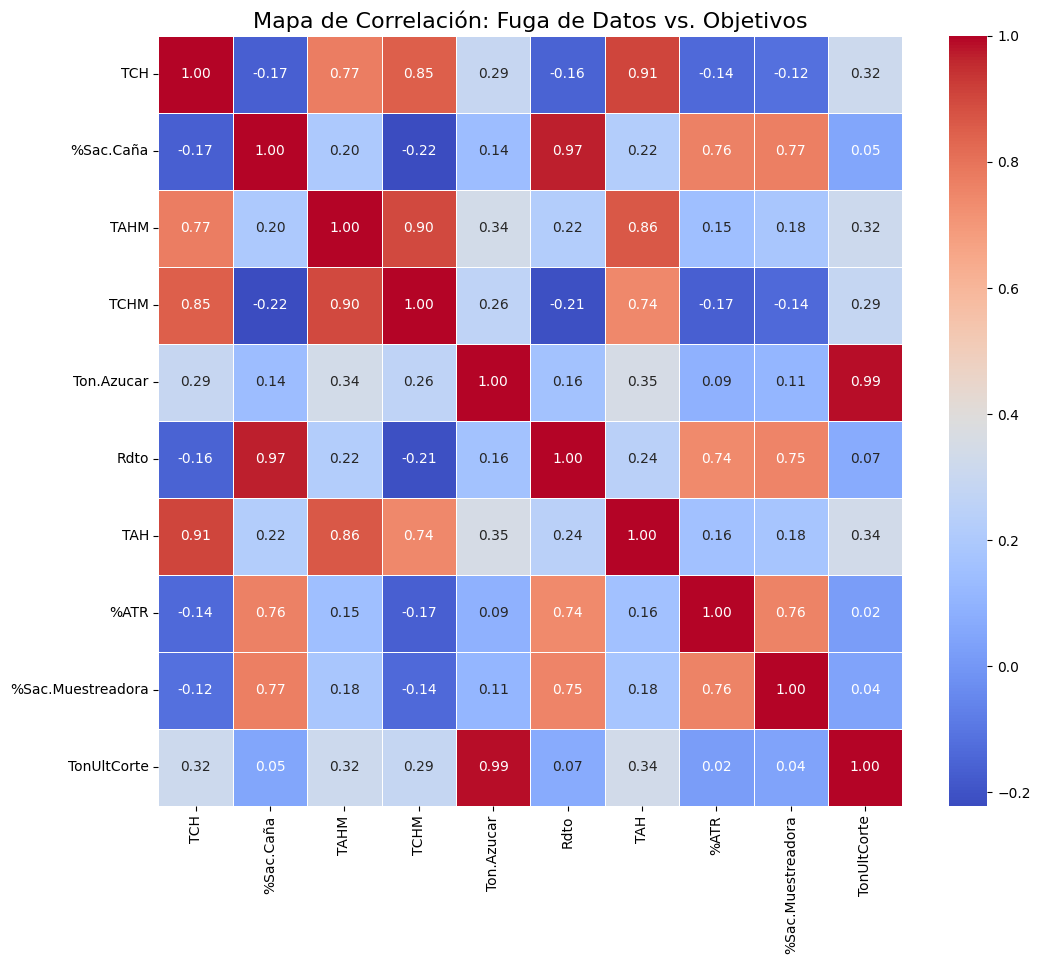

In [61]:
# Lista de variables de fuga de datos + los objetivos
leakage_vars = [
    'TCH',              # Objetivo 1
    '%Sac.Caña',        # Objetivo 2
    'TAHM', 
    'TCHM', 
    'Ton.Azucar', 
    'Rdto', 
    'TAH', 
    '%ATR', 
    '%Sac.Muestreadora', 
    'TonUltCorte'
]

# Crear un sub-dataframe solo con estas columnas
df_leakage = df[leakage_vars].copy()

# Convertir todas las columnas a numéricas para poder calcular la correlación
for col in df_leakage.columns:
    df_leakage[col] = pd.to_numeric(df_leakage[col], errors='coerce')

# Calcular la matriz de correlación
corr_matrix = df_leakage.corr()

# Crear el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Correlación: Fuga de Datos vs. Objetivos', fontsize=16)
plt.show()

Al observar el mapa de calor, podemos concluir

Correlaciones Perfectas o Casi Perfectas cuando observamos los cuadrados de color azul oscuro intenso. Variables como %ATR y %Sac.Muestreadora tienen una correlación de 0.98 y 0.97 con nuestro objetivo %Sac.Caña. De manera similar, Rdto, TAH, Ton.Azucar y TCHM tienen correlaciones altísimas (superiores a 0.8 y 0.9) con TCH.

Una correlación tan cercana a 1.0 no indica simplemente una relación fuerte, esto nos indica que estas variables son, en esencia, la misma información que la variable objetivo, pero expresada de otra manera y no son predictores.

La estadística y la lógica de negocio detrás del gráfico confirman por qué debemos eliminarlas.

El Problema de la Causalidad Inversa es que estadísticamente se busca predictores que causen o influyan en un resultado. Aquí tenemos el problema opuesto: el resultado causa estas variables.

Muchas de estas métricas se calculan directamente a partir de TCH y %Sac.Caña. 

Por ejemplo

Toneladas de Azúcar (Ton.Azucar) se calcula aproximadamente como: (TCH * Area Neta) * (%Sac.Caña / 100) * (Factor de Eficiencia). Como puedes ver, TCH y %Sac.Caña ya están dentro de la fórmula.

* Rendimiento (Rdto) es la cantidad de azúcar producida por tonelada de caña, una métrica derivada directamente de la calidad (%Sac.Caña) y la pureza.
* %ATR (Azúcares Totales Recuperables) es una métrica de laboratorio que es casi idéntica en concepto a %Sac.Caña.
* La Línea de Tiempo del Negocio: Este es el argumento más importante. Piensa en el momento en que usarías el modelo.

Momento de la Predicción antes de la cosecha, en este punto, conoces el Suelo, la Variedad, la F.Siembra y las condiciones climáticas y no puedes conocer el Ton.Azucar final o el Rdto porque la caña aún no ha sido cosechada, transportada y procesada.

Para el momento de la Disponibilidad del Dato solo se conocen despues de que la cosecha ha terminado y se han realizado los análisis en el ingenio.

Lo cual podemos concluit que incluir estas variables en el modelo es como intentar predecir el ganador de un partido de fútbol usando el marcador final como variable predictora. El modelo aprendería una regla perfecta ("si el marcador final es 2-0, el ganador es el equipo que anotó 2 goles"), pero sería completamente inútil para predecir el resultado de un partido antes de que se juegue.

Para construir un modelo predictivo que sea útil para la toma de decisiones futuras, debemos basarnos únicamente en la información que estará disponible en el momento de la predicción. Por esta razón, eliminar estas 8 variables no es una opción, es un requisito fundamental para la integridad y viabilidad del proyecto.

In [63]:
# Teiendo en cuenta lo anterior no se tendra en cuenta las siguientes variables
vars_to_exclude = leakage_vars + ['Nombre', 'Zona', 'Suerte', 'Hacienda', 'Periodo']
vars_predictivas = ['TCH', '%Sac.Caña']

print(vars_to_exclude)

['TCH', '%Sac.Caña', 'TAHM', 'TCHM', 'Ton.Azucar', 'Rdto', 'TAH', '%ATR', '%Sac.Muestreadora', 'TonUltCorte', 'Nombre', 'Zona', 'Suerte', 'Hacienda', 'Periodo']


In [80]:
columnas_a_mantener_ = [col for col in columnas_a_mantener if col not in vars_to_exclude] + vars_predictivas
columnas_a_mantener_

['Edad.Precosecha',
 '%AR Jugo',
 'Período',
 'Lluvias 0 -3',
 'Luvias 9 -FC',
 'Edad Ult Cos',
 '%ME Min',
 'Tenencia',
 'DDUlt.Riego',
 'Lluvias Ciclo',
 'Semanas mad.',
 '%ME Tot',
 '%ME Veg',
 'KATRHM',
 'Lluvias tres a seis',
 'Sac.Caña Precosecha',
 '%Fibra Caña',
 'Dosis Madurante',
 'Lluvias (2 Meses Ant.)',
 'Brix',
 'M3 Riego',
 'Lluvias seis a nueve',
 'TCH',
 '%Sac.Caña']

In [68]:
print(df[columnas_a_mantener_].info())

<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Edad.Precosecha         8908 non-null   float64
 1   %AR Jugo                18903 non-null  float64
 2   Período                 20578 non-null  int64  
 3   Lluvias 0 -3            20578 non-null  float64
 4   Luvias 9 -FC            20578 non-null  float64
 5   Edad Ult Cos            20578 non-null  float64
 6   %ME Min                 19305 non-null  float64
 7   Tenencia                20577 non-null  float64
 8   DDUlt.Riego             20578 non-null  int64  
 9   Lluvias Ciclo           20578 non-null  float64
 10  Semanas mad.            11162 non-null  float64
 11  %ME Tot                 19307 non-null  float64
 12  %ME Veg                 19307 non-null  float64
 13  KATRHM                  20505 non-null  float64
 14  Lluvias tres a seis     20578 non-null  flo

# Imputacion de datos

## Variables Climáticas y de Riego
La variables son Lluvias 0 -3, Luvias 9 -FC, Lluvias Ciclo, Lluvias tres a seis, Lluvias (2 Meses Ant.), Lluvias seis a nueve, DDUlt.Riego, M3 Riego.

Se imputara con la mediana del grupo definido por Zona o Codigo Estacion, ya que el clima es un fenómeno local y al asar la mediana de la misma zona climática o estación meteorológica es la estimación más realista posible del valor faltante

In [69]:
columnas_climaticas = [
    'Lluvias 0 -3',
    'Luvias 9 -FC',
    'DDUlt.Riego',
    'Lluvias Ciclo',
    'Lluvias tres a seis',
    'Lluvias (2 Meses Ant.)',
    'Lluvias seis a nueve',
    'M3 Riego'
]
print(df[columnas_climaticas].info())

<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Lluvias 0 -3            20578 non-null  float64
 1   Luvias 9 -FC            20578 non-null  float64
 2   DDUlt.Riego             20578 non-null  int64  
 3   Lluvias Ciclo           20578 non-null  float64
 4   Lluvias tres a seis     20578 non-null  float64
 5   Lluvias (2 Meses Ant.)  20578 non-null  float64
 6   Lluvias seis a nueve    20578 non-null  float64
 7   M3 Riego                20578 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 1.4 MB
None


In [70]:
for col in columnas_climaticas: df[col] = df.groupby('Zona')[col].transform(lambda x: x.fillna(x.median()))
print(df[columnas_climaticas].info())


<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Lluvias 0 -3            20578 non-null  float64
 1   Luvias 9 -FC            20578 non-null  float64
 2   DDUlt.Riego             20578 non-null  int64  
 3   Lluvias Ciclo           20578 non-null  float64
 4   Lluvias tres a seis     20578 non-null  float64
 5   Lluvias (2 Meses Ant.)  20578 non-null  float64
 6   Lluvias seis a nueve    20578 non-null  float64
 7   M3 Riego                20578 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 1.4 MB
None


Variables de Calidad y Laboratorio
Las aariables son %AR Jugo, %Fibra Caña, Brix, Sac.Caña Precosecha, %ME Min, %ME Veg, %ME Tot.

Se imputara con la mediana del grupo definido por Variedad, ya que las características fisicoquímicas de la caña (fibra, azúcares, etc.) están fuertemente determinadas por su genética. Por lo tanto, la mejor estimación para un valor faltante es la mediana de la misma variedad de caña

In [71]:
columnas_calidad_lab = [
    '%AR Jugo',
    '%ME Min',
    '%ME Tot',
    '%ME Veg',
    'Sac.Caña Precosecha',
    '%Fibra Caña',
    'Brix'
]
print(df[columnas_calidad_lab].info())


<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   %AR Jugo             18903 non-null  float64
 1   %ME Min              19305 non-null  float64
 2   %ME Tot              19307 non-null  float64
 3   %ME Veg              19307 non-null  float64
 4   Sac.Caña Precosecha  19485 non-null  float64
 5   %Fibra Caña          18987 non-null  float64
 6   Brix                 20578 non-null  float64
dtypes: float64(7)
memory usage: 1.3 MB
None


In [74]:
for col in columnas_calidad_lab: df[col] = df.groupby('Variedad')[col].transform(lambda x: x.fillna(x.median()))
print(df[columnas_calidad_lab].info())


<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   %AR Jugo             20578 non-null  float64
 1   %ME Min              20578 non-null  float64
 2   %ME Tot              20578 non-null  float64
 3   %ME Veg              20578 non-null  float64
 4   Sac.Caña Precosecha  20578 non-null  float64
 5   %Fibra Caña          20578 non-null  float64
 6   Brix                 20578 non-null  float64
dtypes: float64(7)
memory usage: 1.3 MB
None


Variables Agronómicas y de Manejo
Las variables son Edad.Precosecha, Edad Ult Cos, Semanas mad., Dosis Madurante, Area Neta.

Se imputara con la mediana del grupo definido por Variedad y/o Tipo de Corte (T.Corte), ya que la duración de los ciclos y las prácticas de manejo (como la dosis de madurante) suelen ser específicas para cada variedad y si es un corte de plantilla o soca. El tamaño de las suertes (Area Neta) también puede ser similar dentro de una misma Hacienda.

In [72]:
columnas_agronomicas = [
    'Edad.Precosecha',
    'Edad Ult Cos',
    'Semanas mad.',
    'Dosis Madurante'
]
print(df[columnas_agronomicas].info())


<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Edad.Precosecha  8908 non-null   float64
 1   Edad Ult Cos     20578 non-null  float64
 2   Semanas mad.     11162 non-null  float64
 3   Dosis Madurante  20482 non-null  float64
dtypes: float64(4)
memory usage: 803.8 KB
None


In [76]:
for col in columnas_agronomicas:
    if col in df.columns:
        df[col] = df.groupby('Variedad')[col].transform(lambda x: x.fillna(x.median()))
print(df[columnas_agronomicas].info())


<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Edad.Precosecha  20578 non-null  float64
 1   Edad Ult Cos     20578 non-null  float64
 2   Semanas mad.     20578 non-null  float64
 3   Dosis Madurante  20578 non-null  float64
dtypes: float64(4)
memory usage: 803.8 KB
None


In [ ]:
columnas_categoricas = [
    'Tenencia'
]
print(df[columnas_categoricas].info())


<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Tenencia  20578 non-null  float64
dtypes: float64(1)
memory usage: 321.5 KB
None


In [79]:
df['Tenencia'] = df.groupby('Hacienda')['Tenencia'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Desconocido"))
print(df[columnas_categoricas].info())


<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Tenencia  20578 non-null  float64
dtypes: float64(1)
memory usage: 321.5 KB
None


In [81]:
df[columnas_a_mantener_]

,Edad.Precosecha,%AR Jugo,Período,Lluvias 0 -3,Luvias 9 -FC,Edad Ult Cos,%ME Min,Tenencia,DDUlt.Riego,Lluvias Ciclo,...,Lluvias tres a seis,Sac.Caña Precosecha,%Fibra Caña,Dosis Madurante,Lluvias (2 Meses Ant.),Brix,M3 Riego,Lluvias seis a nueve,TCH,%Sac.Caña
0,12.12,0.8400,201701,0.0,482.0,12.81,0.3550,51.0,0,1038.0,...,454.0,16.8172,16.9100,1.0,258.0,15.7464,0.0,102.0,121.198333,13.7582
1,12.12,0.5500,201701,0.0,0.0,11.14,2.2980,81.0,0,0.0,...,0.0,16.5438,16.9360,0.0,0.0,15.2240,0.0,0.0,93.793103,12.8430
2,12.02,0.6100,201701,106.0,457.0,12.32,3.0000,31.0,107,1002.0,...,326.0,14.7749,15.5120,1.1,246.0,14.1130,48513.6,113.0,174.347087,11.9364
3,12.06,0.6700,201701,0.0,0.0,9.79,0.1400,82.0,0,0.0,...,0.0,0.0000,17.6210,0.0,0.0,13.6350,0.0,0.0,136.790476,11.2770
4,12.09,0.9500,201701,264.0,284.0,11.53,0.5920,31.0,0,991.0,...,255.0,16.7662,14.3520,0.0,138.0,12.9760,0.0,188.0,113.068432,10.2160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20970,12.06,0.7136,202406,101.0,206.0,12.39,0.2027,31.0,46,613.0,...,191.0,0.0000,14.7223,1.1,80.0,12.5231,176706.0,115.0,89.216708,10.8929
20971,12.06,0.7364,202406,46.0,415.0,12.48,0.1511,11.0,72,828.0,...,271.0,0.0000,15.6200,1.2,276.0,13.2466,417068.1,96.0,139.636640,11.3715
20972,12.06,0.7800,202406,113.0,230.0,13.17,0.1060,31.0,46,625.0,...,176.0,0.0000,17.3830,1.1,80.0,13.2290,26899.2,106.0,98.193181,11.4200
20973,12.22,1.1125,202406,20.0,181.0,11.76,0.1414,31.0,74,546.0,...,226.0,0.0000,19.6983,0.5,153.0,11.6469,81561.6,119.0,181.737639,9.5912


In [82]:
df.describe()

,Período,Hacienda,Tenencia,Area Neta,Dist Km,Cod.Estado #,Edad Ult Cos,Destino 1=Semilla,Cod. T.Cultivo,Producto,...,Evaporacion 0-3,Evaporacion Ciclo,Mes_Siembra,Año_Siembra,Mes_Ult_Corte,Año_Ult_Corte,Mes_Madur,Año_Madur,Mes_Riego,Año_Riego
count,20578.000000,20578.000000,20578.00000,20578.000000,20573.000000,20578.000000,20578.000000,20578.000000,20576.000000,20578.000000,...,4373.000000,4373.000000,20578.000000,20578.000000,20578.000000,20578.000000,11162.000000,11162.000000,8154.000000,8154.000000
mean,202037.465594,80685.554573,46.94742,8.708451,25.510173,4.307221,13.059295,0.000049,1.033388,0.542278,...,442.071416,1924.962840,6.394693,2014.628633,6.426572,2020.310477,6.351460,2020.154273,6.417219,2019.589772
std,216.087850,588.803348,21.27295,7.065561,18.256000,4.120292,1.923714,0.006971,0.179653,0.498221,...,42.327983,300.097679,3.270568,4.811831,3.456079,2.164420,3.501151,2.127264,3.262215,2.372747
min,201701.000000,80100.000000,11.00000,0.004000,1.100000,0.000000,5.550000,0.000000,1.000000,0.000000,...,190.400000,190.400000,1.000000,1986.000000,1.000000,2017.000000,1.000000,2016.000000,1.000000,2016.000000
25%,201812.000000,80261.000000,31.00000,3.384000,12.000000,1.000000,11.960000,0.000000,1.000000,0.000000,...,416.800000,1743.500000,3.000000,2013.000000,3.000000,2018.000000,3.000000,2018.000000,3.000000,2018.000000
50%,202010.000000,80468.000000,51.00000,7.080000,22.000000,3.000000,12.650000,0.000000,1.000000,1.000000,...,440.300000,1892.900000,7.000000,2015.000000,6.000000,2020.000000,6.000000,2020.000000,7.000000,2019.000000
75%,202209.000000,81104.000000,51.00000,12.140000,32.700000,6.000000,13.860000,0.000000,1.000000,1.000000,...,465.000000,2066.000000,9.000000,2018.000000,9.000000,2022.000000,10.000000,2022.000000,9.000000,2022.000000
max,202406.000000,82557.000000,91.00000,65.000000,155.000000,31.000000,78.190000,1.000000,2.000000,1.000000,...,606.900000,4971.800000,12.000000,2023.000000,12.000000,2024.000000,12.000000,2024.000000,12.000000,2024.000000


In [99]:
columns_model = columnas_a_mantener_ + categorical_features
columns_model

['Edad.Precosecha',
 '%AR Jugo',
 'Período',
 'Lluvias 0 -3',
 'Luvias 9 -FC',
 'Edad Ult Cos',
 '%ME Min',
 'Tenencia',
 'DDUlt.Riego',
 'Lluvias Ciclo',
 'Semanas mad.',
 '%ME Tot',
 '%ME Veg',
 'KATRHM',
 'Lluvias tres a seis',
 'Sac.Caña Precosecha',
 '%Fibra Caña',
 'Dosis Madurante',
 'Lluvias (2 Meses Ant.)',
 'Brix',
 'M3 Riego',
 'Lluvias seis a nueve',
 'TCH',
 '%Sac.Caña',
 'Variedad',
 'Cultivo',
 'Producto',
 'Tipo Quema',
 'T.Corte',
 'Mes_Siembra',
 'Año_Siembra',
 'Mes_Ult_Corte',
 'Año_Ult_Corte',
 'Mes_Riego',
 'Año_Riego']

In [112]:
columnas_a_mantener_

['Edad.Precosecha',
 '%AR Jugo',
 'Período',
 'Lluvias 0 -3',
 'Luvias 9 -FC',
 'Edad Ult Cos',
 '%ME Min',
 'Tenencia',
 'DDUlt.Riego',
 'Lluvias Ciclo',
 'Semanas mad.',
 '%ME Tot',
 '%ME Veg',
 'KATRHM',
 'Lluvias tres a seis',
 'Sac.Caña Precosecha',
 '%Fibra Caña',
 'Dosis Madurante',
 'Lluvias (2 Meses Ant.)',
 'Brix',
 'M3 Riego',
 'Lluvias seis a nueve',
 'TCH',
 '%Sac.Caña']

In [113]:
df

,Período,Hacienda,Nombre,Zona,Tenencia,Suerte,Suelo,Area Neta,Dist Km,Variedad,...,Precipitacion 0_3,Precipitacion Ciclo,Evaporacion 0-3,Evaporacion Ciclo,Mes_Siembra,Año_Siembra,Mes_Ult_Corte,Año_Ult_Corte,Mes_Riego,Año_Riego
0,201701,80493,LA CONCHA,IP02,51.0,002A,CANTARINA,6.00,4.3,CC85-92,...,NaN,NaN,NaN,NaN,8,2010,1,2017,0,0
1,201701,81284,UKRANIA INCAUCA,IP05,81.0,039B,NaN,1.45,NaN,CC85-92,...,NaN,NaN,NaN,NaN,1,2011,1,2017,0,0
2,201701,80203,EL AMPARO SAA,IP05,31.0,007,CORINTIAS,8.24,23.0,OTRA,...,NaN,NaN,NaN,NaN,10,2011,1,2017,9,2016
3,201701,81380,SAN JUDAS INCAUCA,IP05,82.0,013A,NaN,1.05,66.5,CC01-1940,...,NaN,NaN,NaN,NaN,3,2014,1,2017,0,0
4,201701,80298,JAVA,IP06,31.0,025A,GALPON,4.53,17.0,RB73-2223,...,NaN,NaN,NaN,NaN,1,2013,1,2017,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20970,202406,80289,EL CARMEN MEJIA,IP01,31.0,001,NIMA,7.96,5.0,CC01-1940,...,182.4,1120.3,518.3,1950.7,9,2018,6,2024,5,2024
20971,202406,82506,EL HIGUERON EMPRESA,IP05,11.0,005A,JOYA,42.74,42.0,CC01-1940,...,NaN,NaN,NaN,NaN,8,2015,6,2024,4,2024
20972,202406,82510,EL CARMEN VELASCO,IP01,31.0,001A,NIMA,1.32,5.0,CC01-1940,...,202.7,1144.3,470.7,2054.0,9,2018,6,2024,5,2024
20973,202406,82530,ARAUCA,IP05,31.0,006,MANUELITA,6.27,34.7,CC05-430,...,NaN,NaN,NaN,NaN,12,2019,6,2024,4,2024


In [114]:
df_ = df.copy()

In [115]:
df = df_[columns_model]

In [116]:
df

,Edad.Precosecha,%AR Jugo,Período,Lluvias 0 -3,Luvias 9 -FC,Edad Ult Cos,%ME Min,Tenencia,DDUlt.Riego,Lluvias Ciclo,...,Cultivo,Producto,Tipo Quema,T.Corte,Mes_Siembra,Año_Siembra,Mes_Ult_Corte,Año_Ult_Corte,Mes_Riego,Año_Riego
0,12.12,0.8400,201701,0.0,482.0,12.81,0.3550,51.0,0,1038.0,...,Normal,1,VERDE,MECANIZADO,8,2010,1,2017,0,0
1,12.12,0.5500,201701,0.0,0.0,11.14,2.2980,81.0,0,0.0,...,Normal,0,Q.ACCIDENTAL,MANUAL,1,2011,1,2017,0,0
2,12.02,0.6100,201701,106.0,457.0,12.32,3.0000,31.0,107,1002.0,...,Normal,1,VERDE,MECANIZADO,10,2011,1,2017,9,2016
3,12.06,0.6700,201701,0.0,0.0,9.79,0.1400,82.0,0,0.0,...,Normal,0,Q.ACCIDENTAL,MANUAL,3,2014,1,2017,0,0
4,12.09,0.9500,201701,264.0,284.0,11.53,0.5920,31.0,0,991.0,...,Normal,0,Q.ACCIDENTAL,MANUAL,1,2013,1,2017,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20970,12.06,0.7136,202406,101.0,206.0,12.39,0.2027,31.0,46,613.0,...,Normal,1,VERDE,MECANIZADO,9,2018,6,2024,5,2024
20971,12.06,0.7364,202406,46.0,415.0,12.48,0.1511,11.0,72,828.0,...,Normal,1,VERDE,MECANIZADO,8,2015,6,2024,4,2024
20972,12.06,0.7800,202406,113.0,230.0,13.17,0.1060,31.0,46,625.0,...,Normal,1,VERDE,MECANIZADO,9,2018,6,2024,5,2024
20973,12.22,1.1125,202406,20.0,181.0,11.76,0.1414,31.0,74,546.0,...,Normal,1,VERDE,MECANIZADO,12,2019,6,2024,4,2024


# Proceso de implementar el modelo

In [101]:
# Modelado y Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [131]:
columnas_a_mantener_ = [col for col in columnas_a_mantener_ if col not in vars_predictivas]
columnas_a_mantener_

['Edad.Precosecha',
 '%AR Jugo',
 'Período',
 'Lluvias 0 -3',
 'Luvias 9 -FC',
 'Edad Ult Cos',
 '%ME Min',
 'Tenencia',
 'DDUlt.Riego',
 'Lluvias Ciclo',
 'Semanas mad.',
 '%ME Tot',
 '%ME Veg',
 'KATRHM',
 'Lluvias tres a seis',
 'Sac.Caña Precosecha',
 '%Fibra Caña',
 'Dosis Madurante',
 'Lluvias (2 Meses Ant.)',
 'Brix',
 'M3 Riego',
 'Lluvias seis a nueve']

In [132]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# columnas_a_mantener_ + categorical_features

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, columnas_a_mantener_),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
# Definir X e y, y separar los datos en conjuntos de entrenamiento y prueba
X = df.drop(columns=['TCH', '%Sac.Caña'])
y_tch = df['TCH']
y_sac = df['%Sac.Caña']

In [123]:
X

,Edad.Precosecha,%AR Jugo,Período,Lluvias 0 -3,Luvias 9 -FC,Edad Ult Cos,%ME Min,Tenencia,DDUlt.Riego,Lluvias Ciclo,...,Cultivo,Producto,Tipo Quema,T.Corte,Mes_Siembra,Año_Siembra,Mes_Ult_Corte,Año_Ult_Corte,Mes_Riego,Año_Riego
0,12.12,0.8400,201701,0.0,482.0,12.81,0.3550,51.0,0,1038.0,...,Normal,1,VERDE,MECANIZADO,8,2010,1,2017,0,0
1,12.12,0.5500,201701,0.0,0.0,11.14,2.2980,81.0,0,0.0,...,Normal,0,Q.ACCIDENTAL,MANUAL,1,2011,1,2017,0,0
2,12.02,0.6100,201701,106.0,457.0,12.32,3.0000,31.0,107,1002.0,...,Normal,1,VERDE,MECANIZADO,10,2011,1,2017,9,2016
3,12.06,0.6700,201701,0.0,0.0,9.79,0.1400,82.0,0,0.0,...,Normal,0,Q.ACCIDENTAL,MANUAL,3,2014,1,2017,0,0
4,12.09,0.9500,201701,264.0,284.0,11.53,0.5920,31.0,0,991.0,...,Normal,0,Q.ACCIDENTAL,MANUAL,1,2013,1,2017,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20970,12.06,0.7136,202406,101.0,206.0,12.39,0.2027,31.0,46,613.0,...,Normal,1,VERDE,MECANIZADO,9,2018,6,2024,5,2024
20971,12.06,0.7364,202406,46.0,415.0,12.48,0.1511,11.0,72,828.0,...,Normal,1,VERDE,MECANIZADO,8,2015,6,2024,4,2024
20972,12.06,0.7800,202406,113.0,230.0,13.17,0.1060,31.0,46,625.0,...,Normal,1,VERDE,MECANIZADO,9,2018,6,2024,5,2024
20973,12.22,1.1125,202406,20.0,181.0,11.76,0.1414,31.0,74,546.0,...,Normal,1,VERDE,MECANIZADO,12,2019,6,2024,4,2024


In [ ]:
#  Dividir los datos en conjuntos de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_tch_train, y_tch_test = train_test_split(X, y_tch, test_size=0.2, random_state=42)
_, _, y_sac_train, y_sac_test = train_test_split(X, y_sac, test_size=0.2, random_state=42)


In [ ]:
# Entrenar y evaluar modelos para TCH
print("\n--- Resultados para TCH (Productividad) ---")
models = {"Ridge (L2)": Ridge(alpha=1.0), "Lasso (L1)": Lasso(alpha=0.1)}
results_tch = {}

for name, model in models.items():
    # Construir el pipeline completo
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    # Entrenar
    pipeline.fit(X_train, y_tch_train)
    
    # Predecir y Evaluar
    y_pred = pipeline.predict(X_test)
    results_tch[name] = [r2_score(y_tch_test, y_pred), 
                         np.sqrt(mean_squared_error(y_tch_test, y_pred)), 
                         mean_absolute_error(y_tch_test, y_pred)]

results_tch_df = pd.DataFrame(results_tch, index=['R²', 'RMSE', 'MAE']).T
print(results_tch_df)


--- Resultados para TCH (Productividad) ---
                  R²       RMSE       MAE
Ridge (L2)  0.902317  10.241668  7.375027
Lasso (L1)  0.901242  10.297859  7.450590


In [ ]:
# Entrenar y evaluar modelos para %Sac.Caña
print("\n--- Resultados para %Sac.Caña (Calidad) ---")
results_sac = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_sac_train)
    y_pred = pipeline.predict(X_test)
    results_sac[name] = [r2_score(y_sac_test, y_pred), 
                         np.sqrt(mean_squared_error(y_sac_test, y_pred)), 
                         mean_absolute_error(y_sac_test, y_pred)]

results_sac_df = pd.DataFrame(results_sac, index=['R²', 'RMSE', 'MAE']).T
print(results_sac_df)



--- Resultados para %Sac.Caña (Calidad) ---
                  R²      RMSE       MAE
Ridge (L2)  0.532709  0.788077  0.586121
Lasso (L1)  0.298825  0.965357  0.746403


In [147]:
from sklearn.model_selection import cross_val_score 

# Metricas TCH

In [154]:
# a) Análisis de Coeficientes del Modelo Lasso para TCH
# (Lasso es ideal para esto por su capacidad de llevar coeficientes a cero)
pipeline_lasso_tch = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Lasso(alpha=0.1))])
pipeline_lasso_tch.fit(X_train, y_tch_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [155]:
results_tch_df = pd.DataFrame(results_tch, index=['R²', 'RMSE', 'MAE']).T
print(results_tch_df)

print("\n--- Evaluación con Validación Cruzada (5-Folds) ---")

# Para R², el scoring es 'r2'
# Se le pasa el pipeline completo, X completo y y_tch completo
scores_r2 = cross_val_score(pipeline_lasso_tch, X, y_tch, cv=5, scoring='r2')

# Para RMSE, el scoring es 'neg_root_mean_squared_error' (devuelve valores negativos)
scores_rmse = cross_val_score(pipeline_lasso_tch, X, y_tch, cv=5, scoring='neg_root_mean_squared_error')
scores_rmse = -scores_rmse # Convertimos a positivo para la interpretación

# Discutir los resultados
print(f"Resultados de R² en cada uno de los 5 Folds: {np.round(scores_r2, 3)}")
print(f"R² Promedio (CV): {scores_r2.mean():.3f} (± {scores_r2.std():.3f})")

print(f"\nResultados de RMSE en cada uno de los 5 Folds: {np.round(scores_rmse, 2)}")
print(f"RMSE Promedio (CV): {scores_rmse.mean():.2f} (± {scores_rmse.std():.2f})")

                  R²       RMSE       MAE
Ridge (L2)  0.902317  10.241668  7.375027
Lasso (L1)  0.901242  10.297859  7.450590

--- Evaluación con Validación Cruzada (5-Folds) ---
Resultados de R² en cada uno de los 5 Folds: [0.818 0.869 0.523 0.831 0.86 ]
R² Promedio (CV): 0.780 (± 0.130)

Resultados de RMSE en cada uno de los 5 Folds: [14.03 11.38 21.93 12.62 11.93]
RMSE Promedio (CV): 14.37 (± 3.88)


In [136]:
numeric_features = columnas_a_mantener_


--- 6. Analizando coeficientes y supuestos del modelo ---


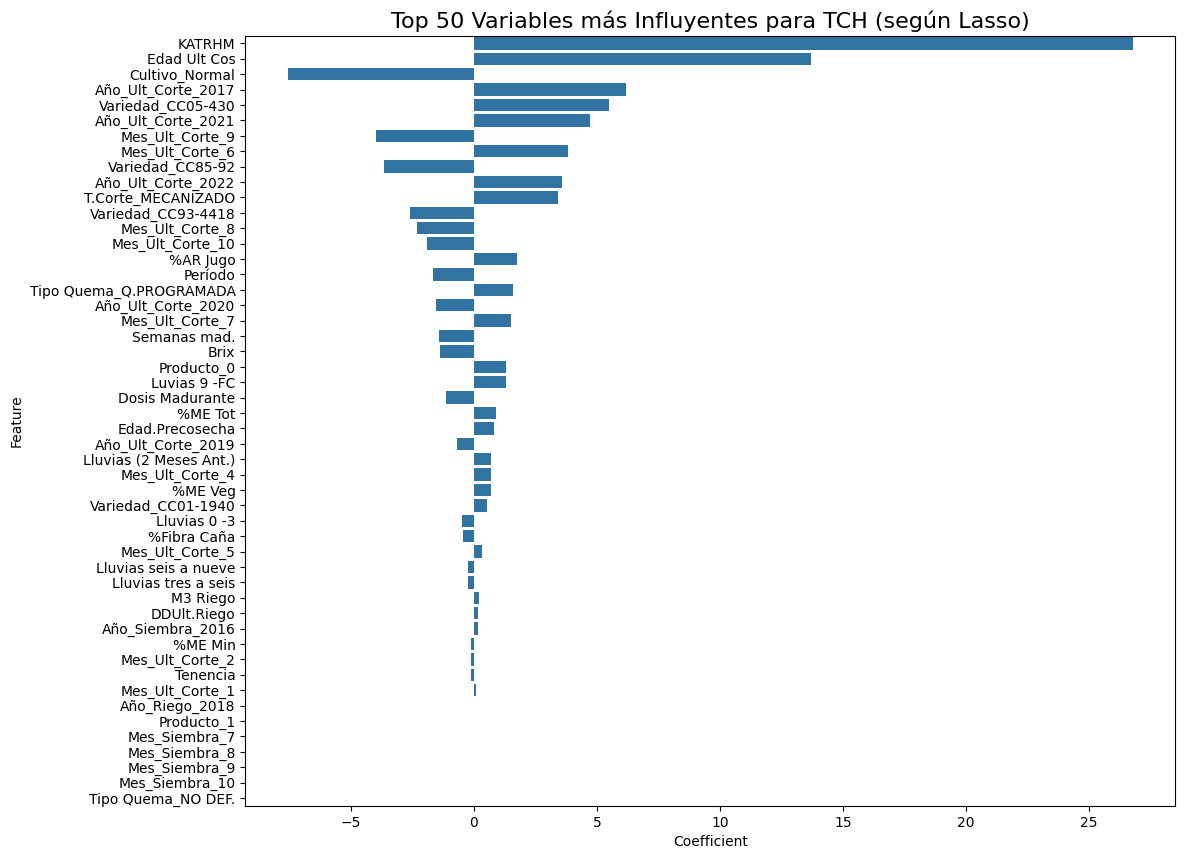

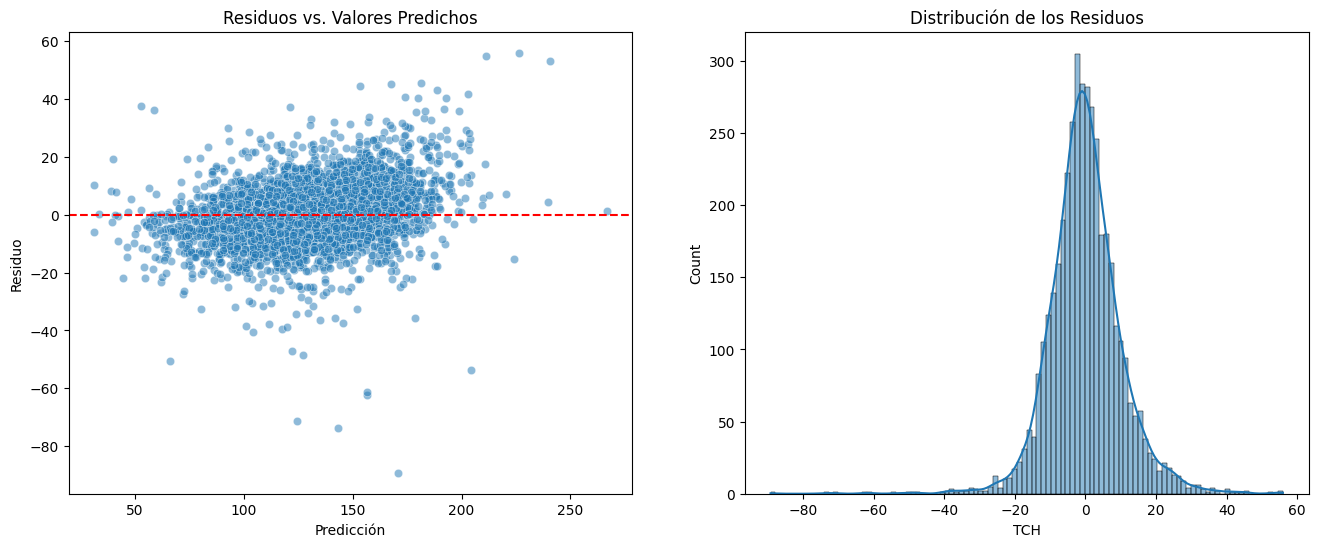

In [ ]:
print("\n--- 6. Analizando coeficientes y supuestos del modelo ---")

# Extraer nombres de features y coeficientes
cat_features_out = pipeline_lasso_tch.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_features_out)
coefficients = pipeline_lasso_tch.named_steps['regressor'].coef_

# Crear un DataFrame y mostrar las variables más importantes
coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
top_20_features = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(50)

plt.figure(figsize=(12, 10))
sns.barplot(x='Coefficient', y='Feature', data=top_20_features)
plt.title('Top 50 Variables más Influyentes para TCH (según Lasso)', fontsize=16)
plt.show()

# b) Evaluación de Supuestos del Modelo (usando Ridge para TCH)
pipeline_ridge_tch = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(alpha=1.0))])
pipeline_ridge_tch.fit(X_train, y_tch_train)
y_pred_diag = pipeline_ridge_tch.predict(X_test)
residuals = y_tch_test - y_pred_diag

# Gráfico de Residuos (Homocedasticidad) y Distribución (Normalidad)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=y_pred_diag, y=residuals, ax=axes[0], alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuos vs. Valores Predichos')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Residuo')

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Distribución de los Residuos')
plt.show()



--- Analizando Coeficientes del Modelo Ridge (L2) ---


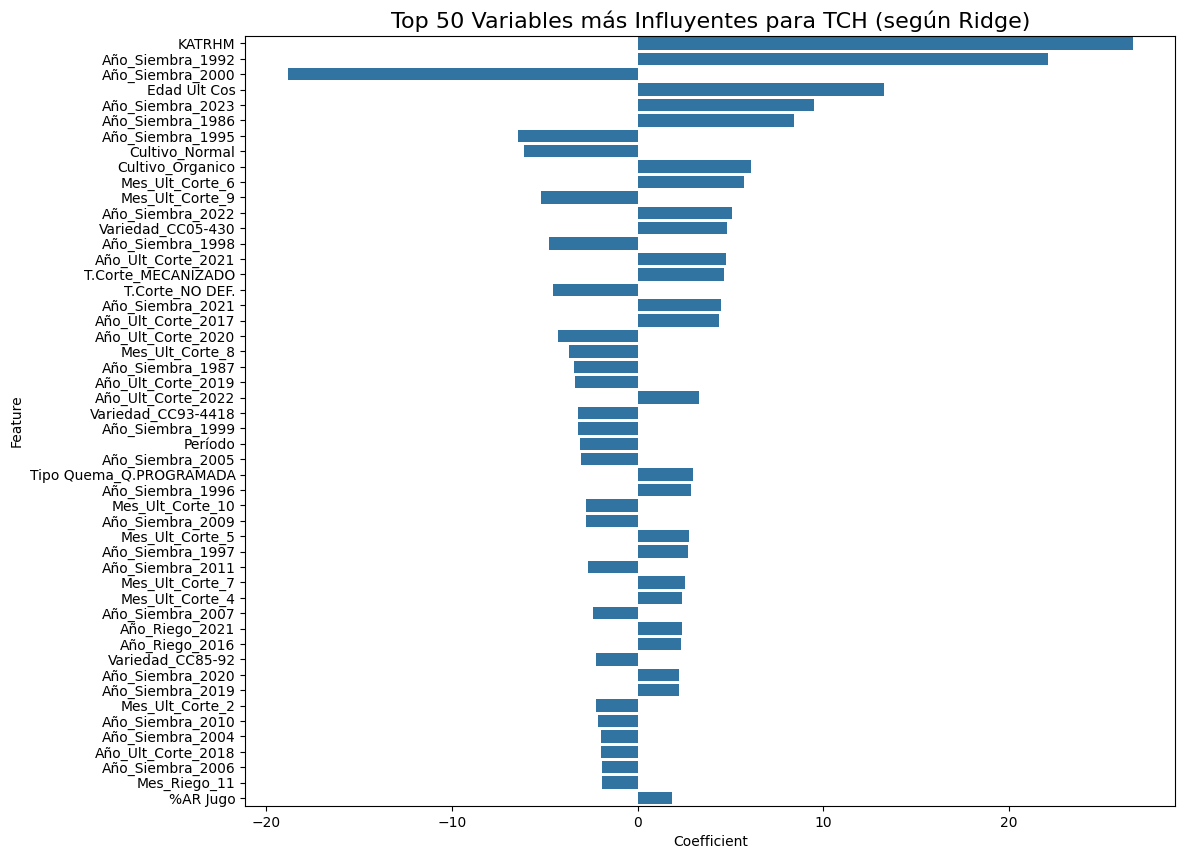

In [ ]:
# --- Análisis de Coeficientes del Modelo Ridge para TCH ---

print("\n--- Analizando Coeficientes del Modelo Ridge (L2) ---")

# Extraer los coeficientes del modelo Ridge
coefficients_ridge = pipeline_ridge_tch.named_steps['regressor'].coef_

# d) Crear un DataFrame para el análisis
coef_df_ridge = pd.DataFrame({'Feature': all_features, 'Coefficient': coefficients_ridge})
coef_df_ridge['Abs_Coefficient'] = coef_df_ridge['Coefficient'].abs()
top_20_features_ridge = coef_df_ridge.sort_values(by='Abs_Coefficient', ascending=False).head(50)

# e) Visualizar los resultados
plt.figure(figsize=(12, 10))
sns.barplot(x='Coefficient', y='Feature', data=top_20_features_ridge)
plt.title('Top 50 Variables más Influyentes para TCH (según Ridge)', fontsize=16)
plt.show()

In [149]:

print("\n--- Evaluación con Validación Cruzada (5-Folds) ---")

# Para R², el scoring es 'r2'
# Se le pasa el pipeline completo, X completo y y_tch completo
scores_r2 = cross_val_score(pipeline_ridge_tch, X, y_tch, cv=5, scoring='r2')

# Para RMSE, el scoring es 'neg_root_mean_squared_error' (devuelve valores negativos)
scores_rmse = cross_val_score(pipeline_ridge_tch, X, y_tch, cv=5, scoring='neg_root_mean_squared_error')
scores_rmse = -scores_rmse # Convertimos a positivo para la interpretación

# Discutir los resultados
print(f"Resultados de R² en cada uno de los 5 Folds: {np.round(scores_r2, 3)}")
print(f"R² Promedio (CV): {scores_r2.mean():.3f} (± {scores_r2.std():.3f})")

print(f"\nResultados de RMSE en cada uno de los 5 Folds: {np.round(scores_rmse, 2)}")
print(f"RMSE Promedio (CV): {scores_rmse.mean():.2f} (± {scores_rmse.std():.2f})")


--- Evaluación con Validación Cruzada (5-Folds) ---
Resultados de R² en cada uno de los 5 Folds: [0.832 0.883 0.526 0.837 0.875]
R² Promedio (CV): 0.791 (± 0.134)

Resultados de RMSE en cada uno de los 5 Folds: [13.5  10.75 21.85 12.41 11.25]
RMSE Promedio (CV): 13.95 (± 4.06)


In [150]:
df['TCH']

0        121.198333
1         93.793103
2        174.347087
3        136.790476
4        113.068432
            ...    
20970     89.216708
20971    139.636640
20972     98.193181
20973    181.737639
20974    108.820604
Name: TCH, Length: 20578, dtype: float64

# Metricas %Sac.Caña

In [157]:
# Análisis de Coeficientes del Modelo Lasso para %Sac.Caña
# (Lasso es ideal para esto por su capacidad de llevar coeficientes a cero)
pipeline_lasso_sac = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Lasso(alpha=0.1))])
pipeline_lasso_sac.fit(X_train, y_sac_train)
# columnas_a_mantener_ + categorical_features

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [159]:
results_sac_df = pd.DataFrame(results_sac, index=['R²', 'RMSE', 'MAE']).T
print(results_sac_df)

print("\n--- Evaluación con Validación Cruzada (5-Folds) ---")

# Para R², el scoring es 'r2'
# Se le pasa el pipeline completo, X completo y y_sac completo
scores_r2 = cross_val_score(pipeline_lasso_sac, X, y_sac, cv=5, scoring='r2')

# Para RMSE, el scoring es 'neg_root_mean_squared_error' (devuelve valores negativos)
scores_rmse = cross_val_score(pipeline_lasso_sac, X, y_sac, cv=5, scoring='neg_root_mean_squared_error')
scores_rmse = -scores_rmse # Convertimos a positivo para la interpretación

# Discutir los resultados
print(f"Resultados de R² en cada uno de los 5 Folds: {np.round(scores_r2, 3)}")
print(f"R² Promedio (CV): {scores_r2.mean():.3f} (± {scores_r2.std():.3f})")

print(f"\nResultados de RMSE en cada uno de los 5 Folds: {np.round(scores_rmse, 2)}")
print(f"RMSE Promedio (CV): {scores_rmse.mean():.2f} (± {scores_rmse.std():.2f})")

                  R²      RMSE       MAE
Ridge (L2)  0.532709  0.788077  0.586121
Lasso (L1)  0.298825  0.965357  0.746403

--- Evaluación con Validación Cruzada (5-Folds) ---
Resultados de R² en cada uno de los 5 Folds: [0.011 0.032 0.342 0.267 0.318]
R² Promedio (CV): 0.194 (± 0.143)

Resultados de RMSE en cada uno de los 5 Folds: [1.02 0.99 0.89 0.99 1.02]
RMSE Promedio (CV): 0.98 (± 0.05)


<!-- # Metricas %Sac.Caña -->


--- 6. Analizando coeficientes y supuestos del modelo ---


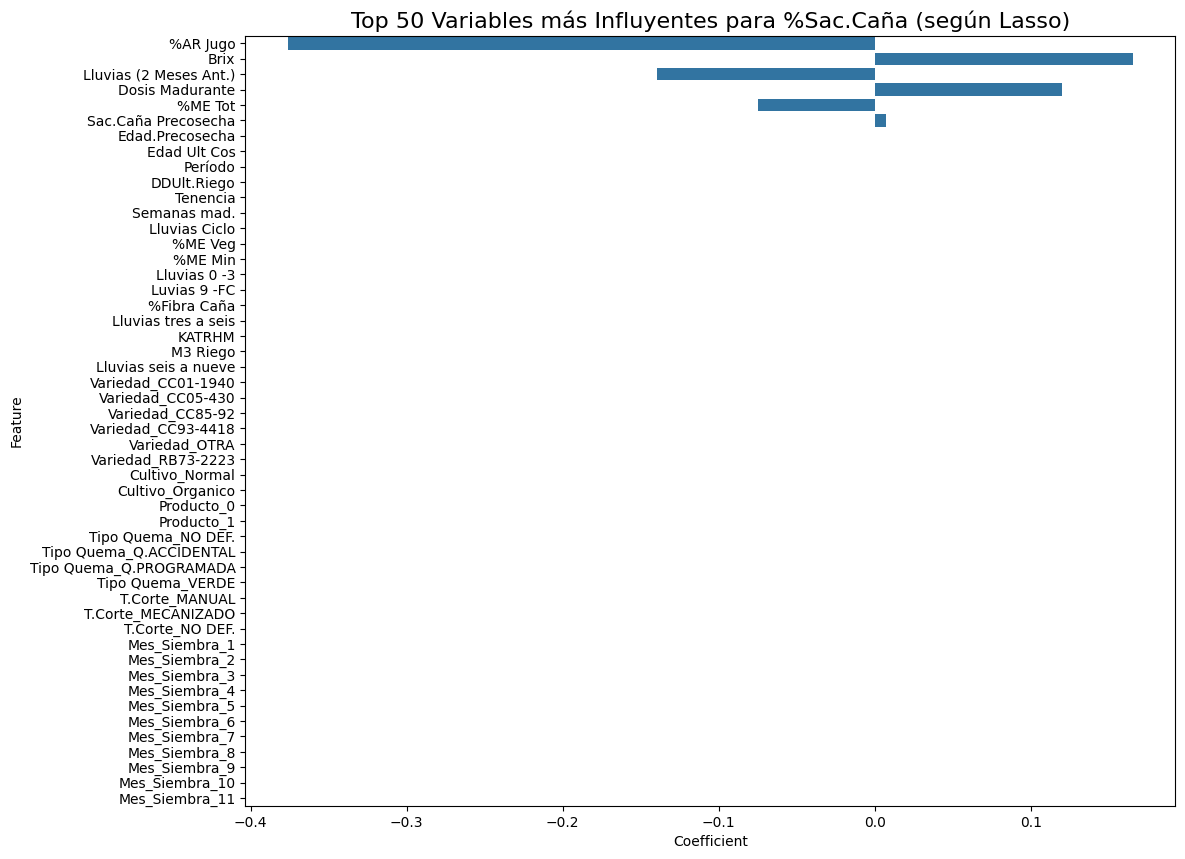

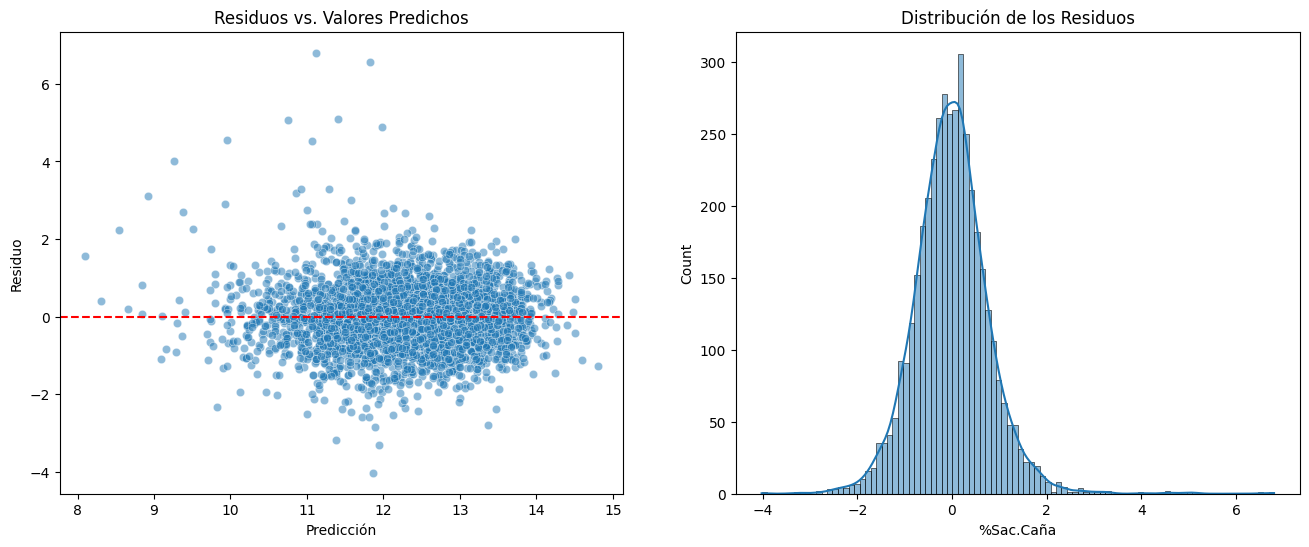

In [160]:
print("\n--- 6. Analizando coeficientes y supuestos del modelo ---")

# Extraer nombres de features y coeficientes
cat_features_out = pipeline_lasso_sac.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_features_out)
coefficients = pipeline_lasso_sac.named_steps['regressor'].coef_

# Crear un DataFrame y mostrar las variables más importantes
coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
top_20_features = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(50)

plt.figure(figsize=(12, 10))
sns.barplot(x='Coefficient', y='Feature', data=top_20_features)
plt.title('Top 50 Variables más Influyentes para %Sac.Caña (según Lasso)', fontsize=16)
plt.show()

# b) Evaluación de Supuestos del Modelo (usando Ridge para %Sac.Caña)
pipeline_ridge_sac = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(alpha=1.0))])
pipeline_ridge_sac.fit(X_train, y_sac_train)
y_pred_diag = pipeline_ridge_sac.predict(X_test)
residuals = y_sac_test - y_pred_diag

# Gráfico de Residuos (Homocedasticidad) y Distribución (Normalidad)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=y_pred_diag, y=residuals, ax=axes[0], alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuos vs. Valores Predichos')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Residuo')

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Distribución de los Residuos')
plt.show()


--- Analizando Coeficientes del Modelo Ridge (L2) ---


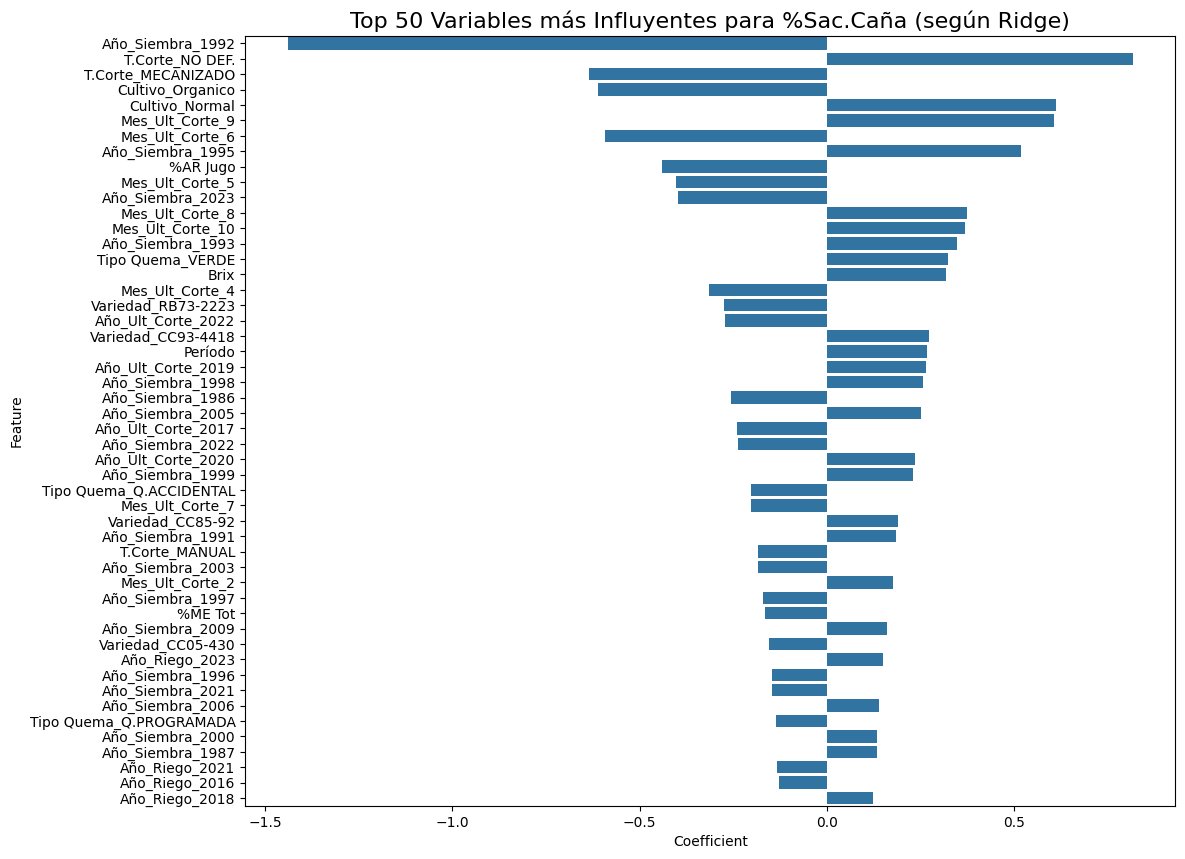

In [ ]:
# --- Análisis de Coeficientes del Modelo Ridge para %Sac.Caña ---

print("\n--- Analizando Coeficientes del Modelo Ridge (L2) ---")

# Extraer los coeficientes del modelo Ridge
coefficients_ridge = pipeline_ridge_sac.named_steps['regressor'].coef_

# Crear un DataFrame para el análisis
coef_df_ridge = pd.DataFrame({'Feature': all_features, 'Coefficient': coefficients_ridge})
coef_df_ridge['Abs_Coefficient'] = coef_df_ridge['Coefficient'].abs()
top_20_features_ridge = coef_df_ridge.sort_values(by='Abs_Coefficient', ascending=False).head(50)

# Visualizar los resultados
plt.figure(figsize=(12, 10))
sns.barplot(x='Coefficient', y='Feature', data=top_20_features_ridge)
plt.title('Top 50 Variables más Influyentes para %Sac.Caña (según Ridge)', fontsize=16)
plt.show()

In [162]:
print("\n--- Evaluación con Validación Cruzada (5-Folds) ---")

# Para R², el scoring es 'r2'
# Se le pasa el pipeline completo, X completo y y_sac completo
scores_r2 = cross_val_score(pipeline_ridge_sac, X, y_sac, cv=5, scoring='r2')

# Para RMSE, el scoring es 'neg_root_mean_squared_error' (devuelve valores negativos)
scores_rmse = cross_val_score(pipeline_ridge_sac, X, y_sac, cv=5, scoring='neg_root_mean_squared_error')
scores_rmse = -scores_rmse # Convertimos a positivo para la interpretación

# Discutir los resultados
print(f"Resultados de R² en cada uno de los 5 Folds: {np.round(scores_r2, 3)}")
print(f"R² Promedio (CV): {scores_r2.mean():.3f} (± {scores_r2.std():.3f})")

print(f"\nResultados de RMSE en cada uno de los 5 Folds: {np.round(scores_rmse, 2)}")
print(f"RMSE Promedio (CV): {scores_rmse.mean():.2f} (± {scores_rmse.std():.2f})")


--- Evaluación con Validación Cruzada (5-Folds) ---
Resultados de R² en cada uno de los 5 Folds: [0.229 0.304 0.51  0.376 0.439]
R² Promedio (CV): 0.372 (± 0.099)

Resultados de RMSE en cada uno de los 5 Folds: [0.9  0.84 0.77 0.91 0.93]
RMSE Promedio (CV): 0.87 (± 0.06)
